In [1]:
import pandas as pd
from pycaret.classification import *
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold, SelectKBest
from sklearn.linear_model import Lasso

In [2]:
clinical = pd.read_csv("data/procdata/TCIA_ISPY2/BRADCURE_analysis/clinical_ISPY2_combined.csv", index_col=0)
radiomics = pd.read_csv("data/procdata/TCIA_ISPY2/BRADCURE_analysis/features_only_ISPY2_combined.csv", index_col=0)

# Clinical Data Preprocessing

In [3]:
# from sklearn.preprocessing import OrdinalEncoder
# Clean menopausal status variable
# Combine all pre, peri, and post menopausal statuses into single categories
# Replace categories not applicable with NA

clinical['menopausal_status'].value_counts(dropna=False)
clinical['cat_menopausal_status'] = clinical['menopausal_status'].replace(to_replace={r'Premenopausal.*': 'Premenopausal',
                                                                                      r'Postmenopausal.*': 'Postmenopausal',
                                                                                      r'Perimenopausal.*': 'Perimenopausal',
                                                                                      r'Above.*': None},
                                                                                      regex=True)
clinical['cat_menopausal_status'] = clinical['cat_menopausal_status'].fillna('NA')

clinical['cat_menopausal_status'].value_counts(dropna=False)

cat_menopausal_status
Premenopausal     480
Postmenopausal    298
NA                172
Perimenopausal     35
Name: count, dtype: int64

In [4]:
# Impute missing age at screening with median age of same menopausal status
# Missing 3 samples are all premenopausal
median_premenopausal_age = clinical[clinical['cat_menopausal_status'] == 'Premenopausal']['Age_at_Screening'].median()

clinical['Age_at_Screening'] = clinical['Age_at_Screening'].fillna(median_premenopausal_age)

# HER2 Prediction

In [5]:
aim_1 = pd.merge(clinical['HER2'], radiomics, left_index=True, right_index=True)

aim_1_train, aim_1_test = train_test_split(aim_1, test_size=0.2, random_state=42, stratify=clinical[['HER2']])

In [6]:
aim_1_train.HER2.value_counts()

HER2
0    593
1    195
Name: count, dtype: int64

In [7]:
aim_1_test.HER2.value_counts()

HER2
0    148
1     49
Name: count, dtype: int64

## Model 1

* 5-fold cross-validation
* Preprocessing enabled
* No feature selection

In [6]:
model_1 = setup(aim_1_train,
                target='HER2',
                session_id=42,
                data_split_stratify=True,
                fold=5,
                preprocess=True,
                experiment_name='BRADCURE_aim1_her2',
          )

best_model_1 = compare_models(cross_validation=True, sort='AUC')

,Description,Value
0,Session id,42
1,Target,HER2
2,Target type,Binary
3,Original data shape,"(788, 1412)"
4,Transformed data shape,"(788, 1412)"
5,Transformed train set shape,"(551, 1412)"
6,Transformed test set shape,"(237, 1412)"
7,Numeric features,1411
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.7459,0.6147,0.0444,0.4500,0.0771,0.0293,0.0627,0.6940
ada,Ada Boost Classifier,0.6915,0.5851,0.2579,0.3293,0.2872,0.0967,0.0976,0.8900
lightgbm,Light Gradient Boosting Machine,0.7423,0.5758,0.1405,0.4161,0.2030,0.1009,0.1204,49.2700
svm,SVM - Linear Kernel,0.7132,0.5741,0.1333,0.1388,0.1337,0.0347,0.0268,0.1140
gbc,Gradient Boosting Classifier,0.7278,0.5688,0.1553,0.3545,0.2129,0.0858,0.0937,4.1320
qda,Quadratic Discriminant Analysis,0.6151,0.5626,0.4114,0.3014,0.3415,0.0840,0.0868,0.1060
ridge,Ridge Classifier,0.7441,0.5454,0.0071,0.1000,0.0133,-0.0098,-0.0094,0.1100
rf,Random Forest Classifier,0.7278,0.5416,0.0963,0.3020,0.1446,0.0394,0.0445,0.2780
et,Extra Trees Classifier,0.7278,0.5414,0.0741,0.2373,0.1089,0.0181,0.0128,0.1480
nb,Naive Bayes,0.3249,0.5346,0.9196,0.2572,0.4019,0.0264,0.0682,0.1080


## Model 2 (bad)

Additions:
* Remove features with variance below 0.3
* Remove features with high correlation with other features (> 0.5)

In [ ]:
model_2 = setup(aim_1_train, 
                target='HER2',
                session_id=42,
                data_split_stratify=True,
                fold=5,
                preprocess=True,
                low_variance_threshold=0.3,
                remove_multicollinearity=True,
                multicollinearity_threshold=0.5,
                experiment_name='BRADCURE_aim1_no_multicol',
          )

In [ ]:
model_2.get_config('X_train_transformed').columns

In [ ]:
compare_models(sort= 'AUC', n_select=5, exclude=['lightgbm', 'knn'])

## Model 3

Additions
* Variance threshold of 0.1
* Feature selection enabled, 45 features 

In [7]:
model_3 = setup(aim_1_train,
                target='HER2',
                session_id=42,
                data_split_stratify=True,
                fold=5,
                preprocess=True,
                low_variance_threshold=0.3,
                remove_multicollinearity=True,
                multicollinearity_threshold=0.9,
                feature_selection = True,
                feature_selection_method = 'classic',
                feature_selection_estimator = 'rf',
                n_features_to_select = 30,
            )

,Description,Value
0,Session id,42
1,Target,HER2
2,Target type,Binary
3,Original data shape,"(788, 1412)"
4,Transformed data shape,"(788, 31)"
5,Transformed train set shape,"(551, 31)"
6,Transformed test set shape,"(237, 31)"
7,Numeric features,1411
8,Preprocess,True
9,Imputation type,simple


In [8]:
model_3.get_config('X_train_transformed').columns

Index(['original_shape_Maximum3DDiameter', 'original_shape_MajorAxisLength',
       'wavelet-LLH_firstorder_Minimum', 'wavelet-LLH_firstorder_Skewness',
       'wavelet-LLH_glcm_ClusterShade',
       'wavelet-LLH_gldm_LargeDependenceHighGrayLevelEmphasis',
       'wavelet-LHL_firstorder_90Percentile',
       'wavelet-LHL_firstorder_Kurtosis', 'wavelet-LHH_firstorder_Kurtosis',
       'wavelet-LHH_glcm_ClusterShade',
       'wavelet-HLL_glszm_LargeAreaHighGrayLevelEmphasis',
       'wavelet-HLH_firstorder_Mean', 'wavelet-HLH_glcm_ClusterShade',
       'wavelet-HHL_glszm_LargeAreaHighGrayLevelEmphasis',
       'wavelet-HHL_gldm_DependenceVariance',
       'wavelet-HHH_firstorder_Kurtosis', 'wavelet-HHH_firstorder_Median',
       'wavelet-HHH_glszm_LargeAreaHighGrayLevelEmphasis',
       'wavelet-LLL_glcm_ClusterShade',
       'squareroot_gldm_LargeDependenceHighGrayLevelEmphasis',
       'logarithm_glcm_ClusterShade', 'logarithm_glcm_DifferenceAverage',
       'logarithm_glcm_DifferenceV

In [9]:
model_3_best = compare_models(sort= 'AUC', n_select=5, exclude=['lightgbm', 'knn'])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.3322,0.5973,0.9259,0.2599,0.4057,0.0335,0.0959,0.7100
lr,Logistic Regression,0.7477,0.5864,0.0220,0.3400,0.0401,0.0112,0.0335,0.8180
lda,Linear Discriminant Analysis,0.7241,0.5827,0.0587,0.2726,0.0956,0.0019,0.0073,0.4020
svm,SVM - Linear Kernel,0.6468,0.5786,0.2000,0.0505,0.0806,-0.0139,-0.0300,0.4240
ada,Ada Boost Classifier,0.7114,0.5597,0.2357,0.3698,0.2854,0.1167,0.1222,0.4380
ridge,Ridge Classifier,0.7477,0.5496,0.0810,0.4550,0.1348,0.0647,0.0996,0.4120
rf,Random Forest Classifier,0.7405,0.5487,0.0960,0.4544,0.1509,0.0647,0.0987,0.4800
gbc,Gradient Boosting Classifier,0.7260,0.5413,0.1331,0.2733,0.1758,0.0598,0.0538,0.5200
et,Extra Trees Classifier,0.7314,0.5256,0.0741,0.2632,0.1123,0.0264,0.0265,0.4600
dt,Decision Tree Classifier,0.6408,0.5021,0.2283,0.2536,0.2397,0.0055,0.0057,0.4300


In [ ]:
predict_model(model_3_best[0], data = aim_1_test)

## Model 4

Trying out data selection independently so can use Lasso, then use pycaret

In [ ]:
aim_1_features = aim_1_train.drop(columns=['HER2'])

variance_selector = VarianceThreshold(threshold=0.2)
variance_selector.fit(aim_1_features)
low_variance_features = aim_1_features[variance_selector.get_feature_names_out(aim_1_features.columns)]

kbest_selector = SelectKBest(k='all')
kbest_selector.fit(low_variance_features, aim_1_train['HER2'])
kbest_features = low_variance_features.loc[:, kbest_selector.scores_ < 0.05]

lasso_selector = Lasso(random_state=42)
lasso_selector.fit(kbest_features, aim_1_train['HER2'])
lasso_selected_features = kbest_features.loc[:,lasso_selector.coef_ != 0]

In [41]:
proc_aim_1_train = pd.merge(aim_1_train['HER2'], lasso_selected_features, left_index=True, right_index=True)

In [43]:
model_4 = setup(proc_aim_1_train,
                target='HER2',
                session_id=42,
                data_split_stratify=True,
                fold=5,
                preprocess=True,
                experiment_name='BRADCURE_aim1_lasso_selected'
                )

,Description,Value
0,Session id,42
1,Target,HER2
2,Target type,Binary
3,Original data shape,"(788, 19)"
4,Transformed data shape,"(788, 19)"
5,Transformed train set shape,"(551, 19)"
6,Transformed test set shape,"(237, 19)"
7,Numeric features,18
8,Preprocess,True
9,Imputation type,simple


In [44]:
model_4_best = compare_models(sort= 'AUC', n_select=5)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.7077,0.6070,0.2063,0.3782,0.2588,0.0953,0.1070,0.0460
gbc,Gradient Boosting Classifier,0.7114,0.5852,0.1180,0.3029,0.1601,0.0287,0.0358,0.0880
et,Extra Trees Classifier,0.7260,0.5842,0.0963,0.2903,0.1427,0.0370,0.0408,0.0540
lightgbm,Light Gradient Boosting Machine,0.6968,0.5686,0.1331,0.2922,0.1622,0.0159,0.0217,37.7920
rf,Random Forest Classifier,0.7405,0.5654,0.0886,0.3568,0.1366,0.0554,0.0696,0.0680
lr,Logistic Regression,0.7223,0.5533,0.0738,0.2650,0.1112,0.0106,0.0124,0.4180
ridge,Ridge Classifier,0.7296,0.5482,0.0148,0.1400,0.0263,-0.0297,-0.0482,0.0120
lda,Linear Discriminant Analysis,0.7241,0.5482,0.0291,0.1917,0.0498,-0.0256,-0.0338,0.0140
qda,Quadratic Discriminant Analysis,0.4211,0.5475,0.7206,0.2587,0.3806,0.0274,0.0402,0.0120
dt,Decision Tree Classifier,0.6533,0.5403,0.3167,0.3035,0.3086,0.0783,0.0787,0.0120


## Model 5
* Normalize data to between 0-1
* Low variance threshold of 0.2
* Multicollinearity_threshhold 0.8

In [45]:
model_5 = setup(aim_1_train,
                target='HER2',
                session_id=42,
                data_split_stratify=True,
                fold=5,
                preprocess=True,
                normalize=True,
                normalize_method='minmax',
                low_variance_threshold=0.2,
                remove_multicollinearity=True,
                multicollinearity_threshold=0.8,
                )

,Description,Value
0,Session id,42
1,Target,HER2
2,Target type,Binary
3,Original data shape,"(788, 1412)"
4,Transformed data shape,"(788, 95)"
5,Transformed train set shape,"(551, 95)"
6,Transformed test set shape,"(237, 95)"
7,Numeric features,1411
8,Preprocess,True
9,Imputation type,simple


In [46]:
model_5_best = compare_models(sort= 'AUC', n_select=5)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7314,0.5611,0.1325,0.3864,0.1940,0.0769,0.0947,36.7240
nb,Naive Bayes,0.4212,0.5582,0.6976,0.3398,0.3621,0.0408,0.0468,0.3380
lr,Logistic Regression,0.7532,0.5558,0.0296,0.3667,0.0547,0.0289,0.0597,0.6880
ada,Ada Boost Classifier,0.7006,0.5522,0.1921,0.3212,0.2306,0.0673,0.0712,0.3820
ridge,Ridge Classifier,0.7423,0.5427,0.0664,0.5133,0.1109,0.0424,0.0847,0.4200
rf,Random Forest Classifier,0.7350,0.5370,0.0519,0.2635,0.0842,0.0146,0.0169,0.4160
gbc,Gradient Boosting Classifier,0.7169,0.5346,0.0960,0.2841,0.1403,0.0212,0.0258,0.6120
svm,SVM - Linear Kernel,0.6477,0.5213,0.2442,0.3764,0.1704,0.0227,0.0591,0.3620
dt,Decision Tree Classifier,0.6280,0.5187,0.3024,0.2704,0.2841,0.0351,0.0352,0.3540
lda,Linear Discriminant Analysis,0.7022,0.5100,0.1101,0.3112,0.1567,0.0127,0.0258,0.3360


## Clinicoradiomic Model

In [7]:
clinical_columns = ['HER2', 'Age_at_Screening', 'cat_menopausal_status']
aim_1 = pd.merge(clinical[clinical_columns], radiomics, left_index=True, right_index=True)

aim_1_train, aim_1_test = train_test_split(aim_1, test_size=0.2, random_state=42, stratify=clinical[['HER2']])

In [84]:
aim_1_features = aim_1_train.drop(columns=clinical_columns)

# Remove features with low variance
variance_selector = VarianceThreshold(threshold=0.5)
variance_selector.fit(aim_1_features)
low_variance_features = aim_1_features[variance_selector.get_feature_names_out(aim_1_features.columns)]

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectFromModel

# Select features using L1-based feature selection
lsvc = LinearSVC(C=0.0001, penalty="l1", dual=False, random_state=42).fit(low_variance_features, aim_1_train['HER2'])
selector = SelectFromModel(lsvc, prefit=True, max_features=15)
selected_features = low_variance_features.loc[:, selector.get_support()]
selected_features.shape


(788, 15)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

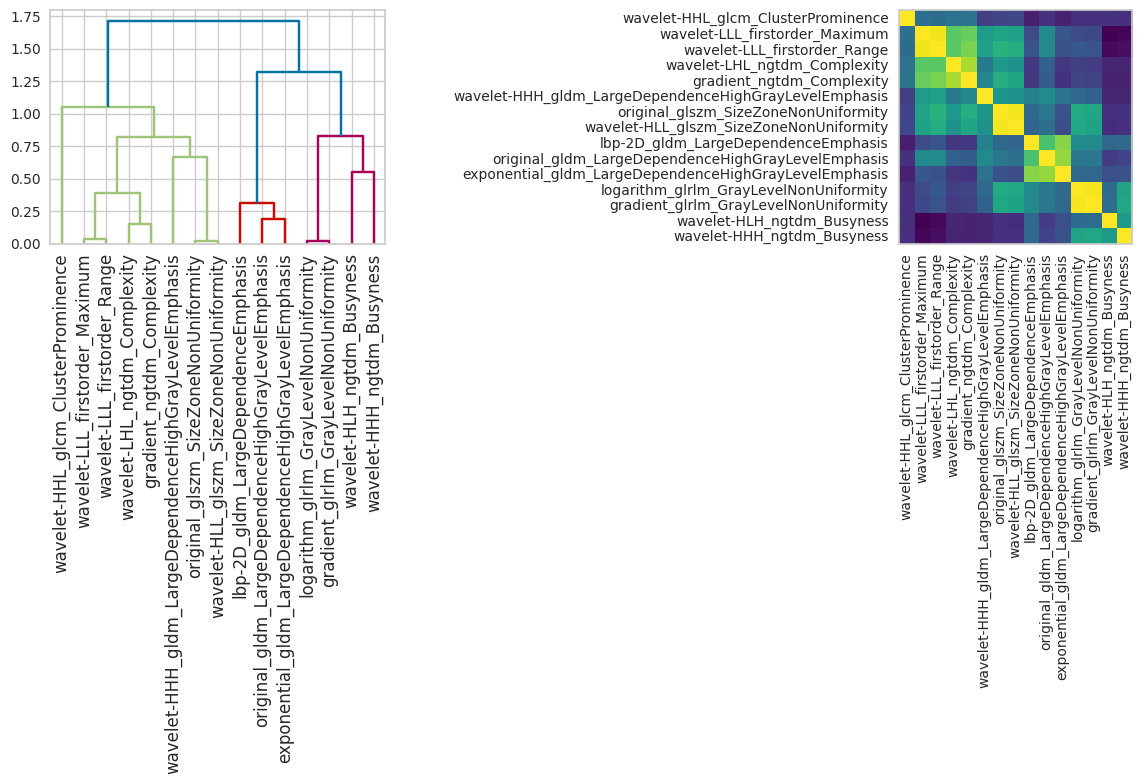

In [87]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr, pearsonr
import matplotlib.pyplot as plt
import numpy as np

# Plot a correlation heatmap and dendrogram to visualize feature correlations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8))
corr = selected_features.corr(method='pearson').to_numpy()

# We convert the correlation matrix to a distance matrix before performing
# hierarchical clustering using Ward's linkage.
distance_matrix = 1 - np.abs(corr)
dist_linkage = hierarchy.ward(squareform(distance_matrix))
dendro = hierarchy.dendrogram(
    dist_linkage, labels=selected_features.columns.to_list(), ax=ax1, leaf_rotation=90
)
dendro_idx = np.arange(0, len(dendro["ivl"]))

ax2.imshow(corr[dendro["leaves"], :][:, dendro["leaves"]], cmap="viridis")
ax2.set_xticks(dendro_idx)
ax2.set_yticks(dendro_idx)
ax2.set_xticklabels(dendro["ivl"], rotation="vertical")
ax2.set_yticklabels(dendro["ivl"])
ax2.grid(None)
_ = fig.tight_layout()

In [93]:
# Add the clinical features back in
proc_aim_1_train = pd.merge(aim_1_train[clinical_columns], selected_features, left_index=True, right_index=True)
proc_aim_1_train

,HER2,Age_at_Screening,cat_menopausal_status,original_glszm_SizeZoneNonUniformity,original_gldm_LargeDependenceHighGrayLevelEmphasis,wavelet-LHL_ngtdm_Complexity,wavelet-HLL_glszm_SizeZoneNonUniformity,wavelet-HLH_ngtdm_Busyness,wavelet-HHL_glcm_ClusterProminence,wavelet-HHH_gldm_LargeDependenceHighGrayLevelEmphasis,wavelet-HHH_ngtdm_Busyness,wavelet-LLL_firstorder_Maximum,wavelet-LLL_firstorder_Range,logarithm_glrlm_GrayLevelNonUniformity,exponential_gldm_LargeDependenceHighGrayLevelEmphasis,gradient_glrlm_GrayLevelNonUniformity,gradient_ngtdm_Complexity,lbp-2D_gldm_LargeDependenceEmphasis
Patient_ID,,,,,,,,,,,,,,,,,,
925691,1,58.0,Postmenopausal,776.731343,3164.835279,78.584645,485.920590,3.276352,1.320171,677.510212,115.582752,2536.006104,1737.549988,1008.430821,461.424138,731.977729,176.777041,380.294430
146033,1,53.0,Perimenopausal,179.445783,84.695122,116.220976,174.295522,1.209695,6.928133,149.416667,4.156996,1746.359863,1070.326782,137.203160,26.544715,49.810420,141.421990,39.211382
294176,0,56.0,NA,42.057851,465.274760,42.966213,39.017699,1.142268,6.151285,507.051118,3.363189,1595.738037,969.900146,62.374715,137.533546,49.546718,139.029632,137.753994
236470,0,54.0,Premenopausal,83.382166,2198.956740,28.557879,109.368298,41.570741,1.443566,337.018567,340.271033,831.923523,560.190918,869.344516,497.800594,952.134879,20.505958,497.800594
578975,0,43.0,Premenopausal,905.593957,1184.314735,47.494382,489.657439,11.468097,0.684527,940.120328,81.706584,1894.527100,1250.865479,1184.392332,222.692122,1051.930042,98.383967,259.595590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522140,0,55.0,NA,40.042254,1358.634948,38.280925,19.050000,12.507965,0.553704,113.242215,115.119399,1105.968384,527.639404,209.763377,352.570934,119.998749,7.208160,143.435986
196024,0,67.0,NA,1182.573427,3525.680515,133.302145,467.309759,366.593975,0.592533,919.053618,1995.103352,1537.868164,1175.427582,12918.457406,521.991006,11522.388635,23.695231,523.793760
570148,1,44.0,Premenopausal,583.852104,1789.590565,10.497104,452.333653,256.396906,0.562299,272.819403,8371.666663,1024.345215,780.429794,8221.166269,380.777863,5969.344599,24.352556,390.356599


In [97]:
cr_model_1 = setup(proc_aim_1_train,
                   index=True,
                   target='HER2',
                   session_id=42,
                   data_split_stratify=True,
                   fold=5,
                   preprocess=True,
                   categorical_features=['cat_menopausal_status'],
                   keep_features=['Age_at_Screening', 'cat_menopausal_status'],
                   experiment_name='BRADCURE_aim1_cr_her2')

,Description,Value
0,Session id,42
1,Target,HER2
2,Target type,Binary
3,Original data shape,"(788, 18)"
4,Transformed data shape,"(788, 21)"
5,Transformed train set shape,"(551, 21)"
6,Transformed test set shape,"(237, 21)"
7,Numeric features,16
8,Categorical features,1
9,Keep features,2


In [98]:
cr_model_1_best = compare_models(sort= 'AUC', n_select=5)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.4356,0.5986,0.8021,0.2781,0.4126,0.0726,0.1115,0.0200
lightgbm,Light Gradient Boosting Machine,0.7060,0.5796,0.1468,0.3086,0.1966,0.0439,0.0496,39.2720
ada,Ada Boost Classifier,0.6914,0.5728,0.1474,0.2698,0.1888,0.0199,0.0213,0.0520
lr,Logistic Regression,0.7350,0.5654,0.0220,0.2686,0.0381,-0.0126,-0.0107,0.4640
gbc,Gradient Boosting Classifier,0.7242,0.5633,0.1325,0.3345,0.1875,0.0620,0.0701,0.0880
rf,Random Forest Classifier,0.7296,0.5602,0.0735,0.3349,0.1165,0.0247,0.0389,0.0740
svm,SVM - Linear Kernel,0.6335,0.5554,0.3743,0.3163,0.3317,0.0896,0.0923,0.0140
lda,Linear Discriminant Analysis,0.7405,0.5513,0.0074,0.0667,0.0133,-0.0174,-0.0462,0.0160
ridge,Ridge Classifier,0.7477,0.5513,0.0074,0.0667,0.0133,-0.0033,-0.0087,0.0180
et,Extra Trees Classifier,0.7078,0.5320,0.0735,0.2203,0.1096,-0.0137,-0.0172,0.0560


## Hatamikia model recreation

https://pmc.ncbi.nlm.nih.gov/articles/PMC10730996/

In [111]:
hatamikia_features = aim_1_train.loc[:,['original_firstorder_InterquartileRange', 
                                        'original_firstorder_Variance', 
                                        'original_glrlm_ShortRunHighGrayLevelEmphasis', 
                                        'original_glcm_DifferenceVariance', 
                                        'original_glszm_LargeAreaHighGrayLevelEmphasis', 
                                        'original_glcm_MCC', 
                                        'original_shape_SurfaceVolumeRatio']]

aim1_hatamikia_train = pd.merge(aim_1_train['HER2'], hatamikia_features, left_index=True, right_index=True)

hatamikia_clf = setup(aim1_hatamikia_train,
                          target='HER2',
                          session_id=42,
                          data_split_stratify=True,
                          fold=5,
                          preprocess=True,
                          experiment_name='BRADCURE_aim1_hatamikia_her2'
                    )

lda = create_model('lda', fold=5, return_train_score=True)


,Description,Value
0,Session id,42
1,Target,HER2
2,Target type,Binary
3,Original data shape,"(788, 8)"
4,Transformed data shape,"(788, 8)"
5,Transformed train set shape,"(551, 8)"
6,Transformed test set shape,"(237, 8)"
7,Numeric features,7
8,Preprocess,True
9,Imputation type,simple


## Hatamikia plus clinical

In [115]:
hat_clin_features = aim_1_train.loc[:,['HER2',
                                       'Age_at_Screening',
                                       'cat_menopausal_status',
                                       'original_firstorder_InterquartileRange', 
                                        'original_firstorder_Variance', 
                                        'original_glrlm_ShortRunHighGrayLevelEmphasis', 
                                        'original_glcm_DifferenceVariance', 
                                        'original_glszm_LargeAreaHighGrayLevelEmphasis', 
                                        'original_glcm_MCC', 
                                        'original_shape_SurfaceVolumeRatio']]

hat_clin_clf = setup(hat_clin_features,
                          target='HER2',
                          session_id=42,
                          data_split_stratify=True,
                          fold=5,
                          preprocess=True,
                          experiment_name='BRADCURE_aim1_hatamikia_her2'
                    )

hat_clin_best = compare_models(sort= 'AUC', n_select=5)

,Description,Value
0,Session id,42
1,Target,HER2
2,Target type,Binary
3,Original data shape,"(788, 10)"
4,Transformed data shape,"(788, 13)"
5,Transformed train set shape,"(551, 13)"
6,Transformed test set shape,"(237, 13)"
7,Numeric features,8
8,Categorical features,1
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
svm,SVM - Linear Kernel,0.7059,0.6063,0.1852,0.2660,0.1982,0.0664,0.0718,0.0180
ada,Ada Boost Classifier,0.7333,0.5576,0.2066,0.4164,0.2736,0.1347,0.1472,0.0340
qda,Quadratic Discriminant Analysis,0.3522,0.5414,0.7500,0.2349,0.3429,-0.0202,-0.0457,0.0180
dt,Decision Tree Classifier,0.6497,0.5375,0.3159,0.2999,0.3077,0.0734,0.0735,0.0200
rf,Random Forest Classifier,0.7460,0.5369,0.1331,0.4508,0.2012,0.1039,0.1314,0.0680
nb,Naive Bayes,0.3902,0.5360,0.7796,0.2577,0.3870,0.0257,0.0405,0.0200
gbc,Gradient Boosting Classifier,0.7459,0.5330,0.1918,0.4658,0.2687,0.1480,0.1699,0.0600
knn,K Neighbors Classifier,0.6914,0.5316,0.1548,0.2988,0.1984,0.0292,0.0357,0.0260
ridge,Ridge Classifier,0.7441,0.5199,0.0000,0.0000,0.0000,-0.0171,-0.0331,0.0160
lda,Linear Discriminant Analysis,0.7386,0.5198,0.0000,0.0000,0.0000,-0.0274,-0.0522,0.0180


## Jing Zhou 2021 model
https://www.sciencedirect.com/science/article/pii/S1076633220303500?casa_token=sl_2To-MwKMAAAAA:Z5XzL98ktP22oOs1UjpnS5wCWltcUo-aYVpQxv0t4sssNKjptcxqVyIMhK0Iub4BCkInnmsOS-A

In [26]:
zhou_features = [
    'exponential_glszm_SmallAreaHighGrayLevelEmphasis',
    'exponential_glszm_GrayLevelVariance',
    'exponential_glcm_Imc2',
    'logarithm_firstorder_10Percentile',
    'exponential_glcm_MCC',
    'wavelet-LHL_firstorder_Minimum',
    'lbp-2D_firstorder_InterquartileRange',
    'wavelet-HHH_firstorder_Minimum',
    'wavelet-HHH_glszm_SmallAreaHighGrayLevelEmphasis',
    'wavelet-HHH_glrlm_ShortRunHighGrayLevelEmphasis',
    'wavelet-LHL_glcm_Correlation',
    'lbp-2D_glcm_MCC',
    'lbp-2D_glcm_Imc2'
]

In [9]:
aim_1a_zhou_train = pd.merge(aim_1_train['HER2'], aim_1_train[zhou_features], left_index=True, right_index=True)
aim_1a_zhou_test = pd.merge(aim_1_test['HER2'], aim_1_test[zhou_features], left_index=True, right_index=True)

In [11]:
zhou_rad_clf = setup(aim_1a_zhou_train,
                     target='HER2',
                     session_id=42,
                     data_split_stratify=True,
                     fold=5,
                     preprocess=True,
                     experiment_name='BRADCURE_aim1a_zhou_her2')

,Description,Value
0,Session id,42
1,Target,HER2
2,Target type,Binary
3,Original data shape,"(788, 14)"
4,Transformed data shape,"(788, 14)"
5,Transformed train set shape,"(551, 14)"
6,Transformed test set shape,"(237, 14)"
7,Numeric features,13
8,Preprocess,True
9,Imputation type,simple


In [31]:
zhou_rad_clf = compare_models(sort = 'AUC', n_select=5)

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,19:58:59
Status,. . . . . . . . . . . . . . . . . .,Loading Estimator
Estimator,. . . . . . . . . . . . . . . . . .,Compiling Library


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.7277,0.5897,0.1180,0.3798,0.1694,0.0575,0.0759,0.0640
ada,Ada Boost Classifier,0.7259,0.5760,0.0960,0.3808,0.1470,0.0408,0.0641,0.0360
lightgbm,Light Gradient Boosting Machine,0.7313,0.5759,0.2272,0.4209,0.2921,0.1457,0.1571,38.2720
rf,Random Forest Classifier,0.7350,0.5510,0.0958,0.3935,0.1530,0.0553,0.0794,0.0640
svm,SVM - Linear Kernel,0.6412,0.5468,0.3042,0.1206,0.1684,0.0404,0.0518,0.0100
et,Extra Trees Classifier,0.7350,0.5324,0.0884,0.3710,0.1396,0.0477,0.0675,0.0480
nb,Naive Bayes,0.5245,0.5285,0.5738,0.2729,0.3635,0.0555,0.0763,0.0100
dt,Decision Tree Classifier,0.6462,0.5256,0.2873,0.2915,0.2889,0.0539,0.0539,0.0100
lda,Linear Discriminant Analysis,0.7550,0.5254,0.0370,0.3667,0.0667,0.0393,0.0775,0.0080
ridge,Ridge Classifier,0.7532,0.5246,0.0148,0.3000,0.0281,0.0147,0.0388,0.0120


In [12]:
zhou_gbc = create_model('gbc')
# save_model(zhou_gbc, 'data/results/zhou_gbc_aim1a_her2')

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,20:18:47
Status,. . . . . . . . . . . . . . . . . .,Selecting Estimator
Estimator,. . . . . . . . . . . . . . . . . .,Gradient Boosting Classifier


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7568,0.6157,0.0714,0.6667,0.1290,0.0843,0.1590
1,0.6818,0.5181,0.1111,0.2143,0.1463,-0.0256,-0.0277
2,0.7091,0.5859,0.0370,0.1429,0.0588,-0.0470,-0.0621
3,0.7364,0.6252,0.1111,0.3750,0.1714,0.0667,0.0843
4,0.7545,0.6037,0.2593,0.5000,0.3415,0.2088,0.2259
Mean,0.7277,0.5897,0.1180,0.3798,0.1694,0.0575,0.0759
Std,0.0286,0.0382,0.0759,0.1899,0.0938,0.0911,0.1089


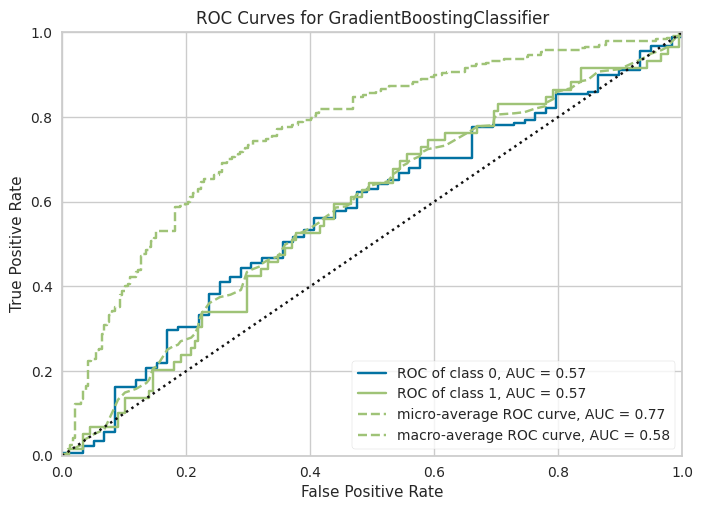

In [13]:
plot_model(zhou_gbc, plot='auc')

In [14]:
predict_model(zhou_gbc, data = aim_1a_zhou_test)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.6802,0.5465,0.1020,0.2083,0.1370,-0.0318,-0.0348


,exponential_glszm_SmallAreaHighGrayLevelEmphasis,exponential_glszm_GrayLevelVariance,exponential_glcm_Imc2,logarithm_firstorder_10Percentile,exponential_glcm_MCC,wavelet-LHL_firstorder_Minimum,lbp-2D_firstorder_InterquartileRange,wavelet-HHH_firstorder_Minimum,wavelet-HHH_glszm_SmallAreaHighGrayLevelEmphasis,wavelet-HHH_glrlm_ShortRunHighGrayLevelEmphasis,wavelet-LHL_glcm_Correlation,lbp-2D_glcm_MCC,lbp-2D_glcm_Imc2,HER2,prediction_label,prediction_score
Patient_ID,,,,,,,,,,,,,,,,
188091,1.578096,0.319375,0.289281,142.421143,0.311296,-48.127674,3.0,-8.359839,0.908219,1.653427,0.098102,1,0.0,1,0,0.9411
639663,0.869022,0.229592,0.009589,223.266403,0.052040,-59.896645,2.0,-8.877539,0.991773,1.841896,0.212200,1,0.0,0,0,0.9477
384830,2.010678,0.728002,0.214864,177.754944,0.241310,-53.509098,2.0,-7.841135,0.527488,2.110924,0.215959,1,0.0,1,0,0.7522
356684,10.914953,4.519379,0.677997,1217.760376,0.533188,-313.846802,2.0,-50.295841,6.046443,10.674899,0.278821,1,0.0,1,0,0.7129
218503,30.524372,12.930100,0.632761,546.259033,0.541504,-123.151299,3.0,-29.511074,3.266227,4.220580,0.130868,1,0.0,0,0,0.8917
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
676630,2.437460,0.644331,0.331170,376.563965,0.381416,-145.648315,4.0,-30.681808,4.396644,4.467554,0.155752,1,0.0,0,0,0.8594
220471,0.211478,0.000000,0.000000,34.069183,1.000000,-21.628010,6.0,-8.600054,1.533916,1.843436,-0.034169,1,0.0,1,0,0.7440
117424,3.064730,1.012942,0.565137,1708.460449,0.493814,-541.017395,4.0,-81.912308,15.394470,14.889710,0.126490,1,0.0,0,0,0.7108


## Clinical model

In [8]:
aim_1a_clin_train = pd.merge(aim_1_train.loc[:, ['HER2']], clinical.loc[:, ['Age_at_Screening', 'cat_menopausal_status']], left_index=True, right_index=True)
aim_1a_clin_test = pd.merge(aim_1_test.loc[:, ['HER2']], clinical.loc[:, ['Age_at_Screening', 'cat_menopausal_status']], left_index=True, right_index=True)


In [9]:
aim_1a_clin_clf = setup(
    aim_1a_clin_train,
    target='HER2',
    session_id=42,
    data_split_stratify=True,
    fold=5,
    preprocess=True,
    categorical_features=['cat_menopausal_status'],
    experiment_name='BRADCURE_aim1a_clin_her2'
)

,Description,Value
0,Session id,42
1,Target,HER2
2,Target type,Binary
3,Original data shape,"(788, 3)"
4,Transformed data shape,"(788, 6)"
5,Transformed train set shape,"(551, 6)"
6,Transformed test set shape,"(237, 6)"
7,Numeric features,1
8,Categorical features,1
9,Preprocess,True


In [11]:
aim_1a_clin_clf_best = compare_models(sort='AUC', n_select=5)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.7532,0.5055,0.0000,0.0000,0.0000,0.0000,0.0000,0.4340
lda,Linear Discriminant Analysis,0.7532,0.5041,0.0000,0.0000,0.0000,0.0000,0.0000,0.0120
ridge,Ridge Classifier,0.7532,0.5037,0.0000,0.0000,0.0000,0.0000,0.0000,0.0120
dummy,Dummy Classifier,0.7532,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0120
nb,Naive Bayes,0.7405,0.4931,0.0587,0.3190,0.0982,0.0307,0.0429,0.0140
lightgbm,Light Gradient Boosting Machine,0.7241,0.4819,0.0296,0.1250,0.0472,-0.0247,-0.0361,27.4480
dt,Decision Tree Classifier,0.7078,0.4809,0.0590,0.1601,0.0851,-0.0281,-0.0424,0.0160
et,Extra Trees Classifier,0.7042,0.4730,0.0590,0.1652,0.0861,-0.0343,-0.0470,0.0600
svm,SVM - Linear Kernel,0.6532,0.4726,0.2815,0.1242,0.1626,0.0445,0.0621,0.0160
ada,Ada Boost Classifier,0.7369,0.4695,0.0074,0.0667,0.0133,-0.0237,-0.0456,0.0360


In [12]:
aim_1a_clin_lr = create_model('lr')
save_model(aim_1a_clin_lr, 'data/results/clin_lr_aim1a_her2')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7477,0.4688,0.0000,0.0000,0.0000,0.0000,0.0000
1,0.7545,0.4728,0.0000,0.0000,0.0000,0.0000,0.0000
2,0.7545,0.5544,0.0000,0.0000,0.0000,0.0000,0.0000
3,0.7545,0.4491,0.0000,0.0000,0.0000,0.0000,0.0000
4,0.7545,0.5821,0.0000,0.0000,0.0000,0.0000,0.0000
Mean,0.7532,0.5055,0.0000,0.0000,0.0000,0.0000,0.0000
Std,0.0027,0.0526,0.0000,0.0000,0.0000,0.0000,0.0000


Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None, include=['Age_at_Screening'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               missing_values=nan,
                                                               strategy='mean'))),
                 ('categorical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['cat_menopausal_status'...
                                                               handle_missing='return_nan',
                                                               handle_unknown='value',
  

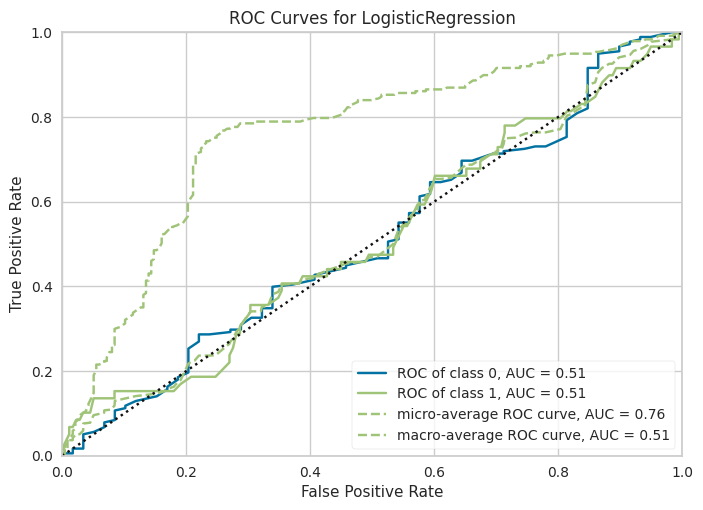

In [21]:
plot_model(aim_1a_clin_lr, 'auc')

In [15]:
predict_model(aim_1a_clin_lr, data = aim_1a_clin_test)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.7513,0.5338,0.0000,0.0000,0.0000,0.0000,0.0000


,Age_at_Screening,cat_menopausal_status,HER2,prediction_label,prediction_score
Patient_ID,,,,,
188091,50.0,Premenopausal,1,0,0.7154
639663,30.0,Premenopausal,0,0,0.8211
384830,37.0,Premenopausal,1,0,0.7880
356684,51.0,Postmenopausal,1,0,0.7665
218503,52.0,Postmenopausal,0,0,0.7610
...,...,...,...,...,...
676630,42.0,NA,0,0,0.8373
220471,50.0,Postmenopausal,1,0,0.7718
117424,33.0,Premenopausal,0,0,0.8075


## Clinical + volume

In [16]:
aim_1a_clinvol_train = pd.merge(aim_1a_clin_train, aim_1_train.loc[:, ['original_shape_MeshVolume']], left_index=True, right_index=True)
aim_1a_clinvol_test = pd.merge(aim_1a_clin_test, aim_1_test.loc[:, ['original_shape_MeshVolume']], left_index=True, right_index=True)

In [18]:
aim_1a_clinvol_clf = setup(
    aim_1a_clinvol_train,
    target='HER2',
    session_id=42,
    data_split_stratify=True,
    fold=5,
    preprocess=True,
    categorical_features=['cat_menopausal_status'],
    experiment_name='BRADCURE_aim1a_clinvol_her2'
)

,Description,Value
0,Session id,42
1,Target,HER2
2,Target type,Binary
3,Original data shape,"(788, 4)"
4,Transformed data shape,"(788, 7)"
5,Transformed train set shape,"(551, 7)"
6,Transformed test set shape,"(237, 7)"
7,Numeric features,2
8,Categorical features,1
9,Preprocess,True


In [19]:
aim_1a_clinvol_clf = compare_models(sort='AUC', n_select=5)

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,20:45:10
Status,. . . . . . . . . . . . . . . . . .,Selecting Estimator
Estimator,. . . . . . . . . . . . . . . . . .,Logistic Regression


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
svm,SVM - Linear Kernel,0.7441,0.5856,0.0812,0.3256,0.1200,0.0540,0.0712,0.0180
ada,Ada Boost Classifier,0.7223,0.5520,0.0735,0.2615,0.1115,0.0104,0.0117,0.0420
gbc,Gradient Boosting Classifier,0.7259,0.5516,0.1619,0.3557,0.2173,0.0852,0.0938,0.0360
rf,Random Forest Classifier,0.6643,0.5471,0.1548,0.2308,0.1849,-0.0157,-0.0163,0.0640
dt,Decision Tree Classifier,0.6497,0.5426,0.3310,0.3131,0.3194,0.0855,0.0861,0.0180
lightgbm,Light Gradient Boosting Machine,0.6824,0.5338,0.1325,0.2420,0.1704,-0.0052,-0.0053,38.1920
et,Extra Trees Classifier,0.6515,0.5321,0.1918,0.2366,0.2110,-0.0076,-0.0083,0.0520
knn,K Neighbors Classifier,0.7405,0.5304,0.1696,0.4030,0.2331,0.1178,0.1306,0.0240
nb,Naive Bayes,0.6717,0.5272,0.1460,0.1995,0.1551,-0.0056,-0.0058,0.3620
ridge,Ridge Classifier,0.7532,0.5021,0.0000,0.0000,0.0000,0.0000,0.0000,0.0200


In [20]:
aim_1a_clinvol_svm = create_model('svm')
save_model(aim_1a_clinvol_svm, "data/results/clinvol_svm_aim1a_her2")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7477,0.5202,0.0357,0.5000,0.0667,0.0342,0.0773
1,0.7545,0.5774,0.0000,0.0000,0.0000,0.0000,0.0000
2,0.7455,0.6814,0.2222,0.4615,0.3000,0.1671,0.1838
3,0.7455,0.5765,0.0370,0.3333,0.0667,0.0185,0.0342
4,0.7273,0.5725,0.1111,0.3333,0.1667,0.0501,0.0610
Mean,0.7441,0.5856,0.0812,0.3256,0.1200,0.0540,0.0712
Std,0.0090,0.0525,0.0792,0.1761,0.1046,0.0590,0.0621


Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Age_at_Screening',
                                              'original_shape_MeshVolume'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               missing_values=nan,
                                                               strategy='mean'))),
                 ('categorical_imputer',
                  TransformerWrapper(exclude=None,
                                     incl...
                 ('trained_model',
                  SGDClassifier(alpha=0.0001, average=False, c

In [ ]:
plot_model(aim_1a_clinvol_rf)

TypeError: AUC plot not available for estimators with no predict_proba attribute.

In [23]:
predict_model(aim_1a_clinvol_svm, data = aim_1a_clinvol_test)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,SVM - Linear Kernel,0.7563,0.5443,0.1224,0.5455,0.2000,0.1197,0.1669


,Age_at_Screening,cat_menopausal_status,original_shape_MeshVolume,HER2,prediction_label
Patient_ID,,,,,
188091,50.0,Premenopausal,5381.500000,1,0
639663,30.0,Premenopausal,6056.333496,0,0
384830,37.0,Premenopausal,705.416687,1,0
356684,51.0,Postmenopausal,492.083344,1,0
218503,52.0,Postmenopausal,7290.541504,0,0
...,...,...,...,...,...
676630,42.0,NA,20327.708984,0,0
220471,50.0,Postmenopausal,1760.083374,1,0
117424,33.0,Premenopausal,22085.791016,0,0


## Clinical + Radiomic

In [27]:
aim_1a_cr_train = pd.merge(aim_1a_clin_train, aim_1_train[zhou_features], left_index=True, right_index=True)
aim_1a_cr_test = pd.merge(aim_1a_clin_test, aim_1_test[zhou_features], left_index=True, right_index=True)

In [28]:
aim_1a_cr_clf = setup(
    aim_1a_cr_train,
    target='HER2',
    session_id=42,
    data_split_stratify=True,
    fold=5,
    preprocess=True,
    categorical_features=['cat_menopausal_status'],
    experiment_name='BRADCURE_aim1a_clinrad_her2'
)

,Description,Value
0,Session id,42
1,Target,HER2
2,Target type,Binary
3,Original data shape,"(788, 16)"
4,Transformed data shape,"(788, 19)"
5,Transformed train set shape,"(551, 19)"
6,Transformed test set shape,"(237, 19)"
7,Numeric features,14
8,Categorical features,1
9,Preprocess,True


In [29]:
aim_1a_cr_clf_best = compare_models(sort='auc', n_select=5)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.7187,0.5789,0.1254,0.3168,0.1777,0.0477,0.0546,0.0700
ada,Ada Boost Classifier,0.7187,0.5781,0.1479,0.3170,0.1981,0.0632,0.0667,0.0600
lightgbm,Light Gradient Boosting Machine,0.7096,0.5720,0.1608,0.3111,0.2102,0.0579,0.0613,38.2560
rf,Random Forest Classifier,0.7405,0.5578,0.0738,0.3652,0.1224,0.0448,0.0641,0.0720
lda,Linear Discriminant Analysis,0.7514,0.5164,0.0516,0.3250,0.0843,0.0429,0.0618,0.0240
nb,Naive Bayes,0.5445,0.5155,0.3910,0.2274,0.2769,-0.0243,-0.0100,0.0180
ridge,Ridge Classifier,0.7496,0.5144,0.0148,0.1333,0.0267,0.0070,-0.0002,0.0180
svm,SVM - Linear Kernel,0.7532,0.5117,0.0000,0.0000,0.0000,0.0000,0.0000,0.0200
lr,Logistic Regression,0.7495,0.5112,0.0148,0.2000,0.0276,0.0077,0.0177,0.3660
dummy,Dummy Classifier,0.7532,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0200


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [30]:
aim_1a_cr_gbc = create_model('gbc')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7117,0.6235,0.0714,0.2500,0.1111,-0.0011,-0.0014
1,0.6818,0.5301,0.0741,0.1667,0.1026,-0.0571,-0.0641
2,0.7364,0.5694,0.1111,0.3750,0.1714,0.0667,0.0843
3,0.7273,0.6167,0.1481,0.3636,0.2105,0.0798,0.0915
4,0.7364,0.5547,0.2222,0.4286,0.2927,0.1502,0.1625
Mean,0.7187,0.5789,0.1254,0.3168,0.1777,0.0477,0.0546
Std,0.0205,0.0360,0.0559,0.0949,0.0699,0.0711,0.0789


In [31]:
save_model(aim_1a_cr_gbc, "data/results/cr_gbc_aim1a_her2")

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Age_at_Screening',
                                              'exponential_glszm_SmallAreaHighGrayLevelEmphasis',
                                              'exponential_glszm_GrayLevelVariance',
                                              'exponential_glcm_Imc2',
                                              'logarithm_firstorder_10Percentile',
                                              'exponential_glcm_MCC',
                                              'wavelet-LHL_firstorder_Minimum',
                                              'lbp-2D_firstorder_...
                                             criterion='friedman_mse', init=None,
                                             learning_rate=0.1, loss='log_loss',
                                             max_depth=3, max_features=None,
        

In [32]:
predict_model(aim_1a_cr_gbc, data = aim_1a_cr_test)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Gradient Boosting Classifier,0.6904,0.5467,0.0816,0.2000,0.1159,-0.0330,-0.0379


,Age_at_Screening,cat_menopausal_status,exponential_glszm_SmallAreaHighGrayLevelEmphasis,exponential_glszm_GrayLevelVariance,exponential_glcm_Imc2,logarithm_firstorder_10Percentile,exponential_glcm_MCC,wavelet-LHL_firstorder_Minimum,lbp-2D_firstorder_InterquartileRange,wavelet-HHH_firstorder_Minimum,wavelet-HHH_glszm_SmallAreaHighGrayLevelEmphasis,wavelet-HHH_glrlm_ShortRunHighGrayLevelEmphasis,wavelet-LHL_glcm_Correlation,lbp-2D_glcm_MCC,lbp-2D_glcm_Imc2,HER2,prediction_label,prediction_score
Patient_ID,,,,,,,,,,,,,,,,,,
188091,50.0,Premenopausal,1.578096,0.319375,0.289281,142.421143,0.311296,-48.127674,3.0,-8.359839,0.908219,1.653427,0.098102,1,0.0,1,0,0.9730
639663,30.0,Premenopausal,0.869022,0.229592,0.009589,223.266403,0.052040,-59.896645,2.0,-8.877539,0.991773,1.841896,0.212200,1,0.0,0,0,0.9513
384830,37.0,Premenopausal,2.010678,0.728002,0.214864,177.754944,0.241310,-53.509098,2.0,-7.841135,0.527488,2.110924,0.215959,1,0.0,1,0,0.8135
356684,51.0,Postmenopausal,10.914953,4.519379,0.677997,1217.760376,0.533188,-313.846802,2.0,-50.295841,6.046443,10.674899,0.278821,1,0.0,1,0,0.7448
218503,52.0,Postmenopausal,30.524372,12.930100,0.632761,546.259033,0.541504,-123.151299,3.0,-29.511074,3.266227,4.220580,0.130868,1,0.0,0,0,0.8558
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
676630,42.0,NA,2.437460,0.644331,0.331170,376.563965,0.381416,-145.648315,4.0,-30.681808,4.396644,4.467554,0.155752,1,0.0,0,0,0.8342
220471,50.0,Postmenopausal,0.211478,0.000000,0.000000,34.069183,1.000000,-21.628010,6.0,-8.600054,1.533916,1.843436,-0.034169,1,0.0,1,0,0.7251
117424,33.0,Premenopausal,3.064730,1.012942,0.565137,1708.460449,0.493814,-541.017395,4.0,-81.912308,15.394470,14.889710,0.126490,1,0.0,0,0,0.8347


# HR Prediction

In [5]:
clinical_columns = ['HR', 'Age_at_Screening', 'cat_menopausal_status']
aim_1b = pd.merge(clinical[clinical_columns], radiomics, left_index=True, right_index=True)

aim_1b_train, aim_1b_test = train_test_split(aim_1b, test_size=0.2, random_state=42, stratify=clinical[['HR']])

aim_1b_train.HR.value_counts()

HR
1    430
0    358
Name: count, dtype: int64

In [6]:
aim_1b_test.HR.value_counts()

HR
1    107
0     90
Name: count, dtype: int64

## Radiomic models

In [17]:
aim_1b_radiomic_train = aim_1b_train.drop(['Age_at_Screening', 'cat_menopausal_status'], axis=1)
aim_1b_radiomic_test = aim_1b_test.drop(['Age_at_Screening', 'cat_menopausal_status'], axis=1)
aim_1b_rad_clf = setup(aim_1b_radiomic_train,
                      index=True,
                      target='HR',
                      session_id=42,
                      data_split_stratify=True,
                      fold=5,
                      preprocess=True,
                      low_variance_threshold=0.3,
                      remove_multicollinearity=True,
                      multicollinearity_threshold=0.9,
                      feature_selection = True,
                      feature_selection_method = 'univariate',
                      feature_selection_estimator = 'rf',
                      n_features_to_select = 10,
)

,Description,Value
0,Session id,42
1,Target,HR
2,Target type,Binary
3,Original data shape,"(788, 1412)"
4,Transformed data shape,"(788, 11)"
5,Transformed train set shape,"(551, 11)"
6,Transformed test set shape,"(237, 11)"
7,Numeric features,1411
8,Preprocess,True
9,Imputation type,simple


Index(['wavelet-HLH_gldm_LargeDependenceHighGrayLevelEmphasis',
       'exponential_firstorder_Energy', 'exponential_glcm_DifferenceAverage',
       'exponential_glszm_SizeZoneNonUniformity',
       'exponential_gldm_DependenceVariance', 'gradient_firstorder_Kurtosis',
       'lbp-2D_firstorder_90Percentile',
       'lbp-2D_firstorder_InterquartileRange', 'lbp-2D_firstorder_Kurtosis',
       'lbp-2D_firstorder_Variance'],
      dtype='object')

In [13]:
aim_1b_rad_clf.get_config('X_train_transformed').columns

Index(['wavelet-HLH_gldm_LargeDependenceHighGrayLevelEmphasis',
       'exponential_firstorder_Energy', 'exponential_glcm_DifferenceAverage',
       'exponential_glszm_SizeZoneNonUniformity',
       'exponential_gldm_DependenceVariance', 'exponential_ngtdm_Strength',
       'gradient_firstorder_Kurtosis', 'lbp-2D_firstorder_90Percentile',
       'lbp-2D_firstorder_InterquartileRange', 'lbp-2D_firstorder_Kurtosis',
       'lbp-2D_firstorder_Variance'],
      dtype='object')

In [14]:
#11 features
aim_1b_rad_clf_best = compare_models(sort= 'AUC', n_select=5)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.5099,0.5518,0.4807,0.3363,0.3944,0.0258,0.0313,0.3660
dt,Decision Tree Classifier,0.5264,0.5259,0.5317,0.5728,0.5506,0.0513,0.0519,0.3460
nb,Naive Bayes,0.5208,0.5234,0.7406,0.5066,0.5761,-0.0000,0.0013,0.3840
gbc,Gradient Boosting Classifier,0.5444,0.5192,0.6710,0.5698,0.6159,0.0644,0.0663,0.4320
ridge,Ridge Classifier,0.5299,0.5186,0.7107,0.5540,0.6220,0.0235,0.0257,0.3820
lda,Linear Discriminant Analysis,0.5281,0.5186,0.7107,0.5525,0.6211,0.0194,0.0214,0.3420
et,Extra Trees Classifier,0.5426,0.5176,0.6575,0.5690,0.6091,0.0630,0.0654,0.3840
rf,Random Forest Classifier,0.5208,0.5004,0.6179,0.5552,0.5842,0.0222,0.0224,0.4460
dummy,Dummy Classifier,0.5463,0.5000,1.0000,0.5463,0.7066,0.0000,0.0000,0.3420
knn,K Neighbors Classifier,0.5101,0.4969,0.5850,0.5479,0.5648,0.0052,0.0057,0.3500


In [11]:
#12 features
aim_1b_rad_clf_best = compare_models(sort= 'AUC', n_select=5)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.5226,0.5263,0.7373,0.5095,0.5711,0.0040,0.0053,0.3980
et,Extra Trees Classifier,0.5353,0.5224,0.6308,0.5655,0.5957,0.0519,0.0535,0.4180
gbc,Gradient Boosting Classifier,0.5427,0.5219,0.6446,0.5715,0.6053,0.0657,0.0671,0.4040
rf,Random Forest Classifier,0.5445,0.5175,0.6279,0.5760,0.6006,0.0726,0.0731,0.3940
ridge,Ridge Classifier,0.5299,0.5167,0.7041,0.5547,0.6199,0.0249,0.0268,0.3760
lda,Linear Discriminant Analysis,0.5281,0.5167,0.7041,0.5532,0.6190,0.0208,0.0225,0.3660
lr,Logistic Regression,0.4845,0.5163,0.4008,0.3108,0.3411,-0.0129,-0.0055,0.8700
lightgbm,Light Gradient Boosting Machine,0.5408,0.5162,0.6278,0.5730,0.5983,0.0643,0.0646,26.8140
dummy,Dummy Classifier,0.5463,0.5000,1.0000,0.5463,0.7066,0.0000,0.0000,0.3400
qda,Quadratic Discriminant Analysis,0.4827,0.4993,0.4673,0.5208,0.4505,-0.0330,-0.0462,0.4380


In [15]:
aim_1b_rad_lr = create_model('lr')
# save_model(aim_1b_rad_lr, 'data/results/radiomic_lr_aim1b_hr')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5405,0.5528,0.7869,0.5581,0.6531,0.0282,0.0320
1,0.5545,0.5867,0.9167,0.5556,0.6918,0.0392,0.0609
2,0.4545,0.5193,0.0000,0.0000,0.0000,0.0000,0.0000
3,0.5455,0.5447,0.7000,0.5676,0.6269,0.0614,0.0637
4,0.4545,0.5553,0.0000,0.0000,0.0000,0.0000,0.0000
Mean,0.5099,0.5518,0.4807,0.3363,0.3944,0.0258,0.0313
Std,0.0454,0.0216,0.3985,0.2746,0.3226,0.0236,0.0279


In [16]:
predict_model(aim_1b_rad_lr, data = aim_1b_test)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.4569,0.5073,0.0000,0.0000,0.0000,0.0000,0.0000


,Age_at_Screening,cat_menopausal_status,original_shape_MeshVolume,original_shape_VoxelVolume,original_shape_SurfaceArea,original_shape_SurfaceVolumeRatio,original_shape_Sphericity,original_shape_Compactness1,original_shape_SphericalDisproportion,original_shape_Maximum3DDiameter,...,lbp-2D_gldm_SmallDependenceHighGrayLevelEmphasis,lbp-2D_gldm_SmallDependenceLowGrayLevelEmphasis,lbp-2D_ngtdm_Busyness,lbp-2D_ngtdm_Coarseness,lbp-2D_ngtdm_Complexity,lbp-2D_ngtdm_Contrast,lbp-2D_ngtdm_Strength,HR,prediction_label,prediction_score
Patient_ID,,,,,,,,,,,,,,,,,,,,,
156163,47.0,Premenopausal,7413.625000,8569.0,16182.596680,2.182818,0.113620,0.002032,8.801236,157.066864,...,0.018481,0.018481,0.0,1000000.0,0.0,0.0,0.0,1,0,0.5016
240432,48.0,Postmenopausal,86983.710938,88283.0,42276.199219,0.486024,0.224567,0.005646,4.453005,188.374634,...,0.003184,0.003184,0.0,1000000.0,0.0,0.0,0.0,1,0,0.5201
145777,30.0,NA,10797.333008,10940.0,5794.626465,0.536672,0.407696,0.013810,2.452808,52.009613,...,0.003287,0.003287,0.0,1000000.0,0.0,0.0,0.0,1,0,0.5034
324021,44.0,NA,5176.166504,5599.0,9650.427734,1.864397,0.149949,0.003080,6.668942,92.720009,...,0.014730,0.014730,0.0,1000000.0,0.0,0.0,0.0,1,0,0.5011
345907,61.0,Postmenopausal,6350.458496,6453.0,4865.523926,0.766169,0.340846,0.010557,2.933878,70.978867,...,0.004090,0.004090,0.0,1000000.0,0.0,0.0,0.0,0,0,0.5018
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745633,56.0,Postmenopausal,1629.833374,1660.0,1987.062622,1.219181,0.337055,0.010381,2.966871,64.226166,...,0.009373,0.009373,0.0,1000000.0,0.0,0.0,0.0,1,0,0.5088
735673,44.0,Premenopausal,2216.708252,2786.0,5572.503906,2.513864,0.147539,0.003006,6.777880,198.610168,...,0.025013,0.025013,0.0,1000000.0,0.0,0.0,0.0,1,0,0.5025
810965,66.0,Postmenopausal,2253.125000,2464.0,3878.671875,1.721463,0.214285,0.005262,4.666687,118.021187,...,0.010841,0.010841,0.0,1000000.0,0.0,0.0,0.0,0,0,0.5007


## Clinical Model

In [7]:
aim_1b_clin_train = pd.merge(aim_1b_train.loc[:, ['HR']], clinical.loc[:, ['Age_at_Screening', 'cat_menopausal_status']], left_index=True, right_index=True)
aim_1b_clin_test = pd.merge(aim_1b_test.loc[:, ['HR']], clinical.loc[:, ['Age_at_Screening', 'cat_menopausal_status']], left_index=True, right_index=True)


In [39]:
aim_1b_clin_clf = setup(
    aim_1b_clin_train,
    target='HR',
    session_id=42,
    data_split_stratify=True,
    fold=5,
    preprocess=True,
    categorical_features=['cat_menopausal_status'],
    experiment_name='BRADCURE_aim1a_clin_hr'
)

,Description,Value
0,Session id,42
1,Target,HR
2,Target type,Binary
3,Original data shape,"(788, 3)"
4,Transformed data shape,"(788, 6)"
5,Transformed train set shape,"(551, 6)"
6,Transformed test set shape,"(237, 6)"
7,Numeric features,1
8,Categorical features,1
9,Preprocess,True


In [41]:
aim_1b_clin_clf_best = compare_models(sort='auc', n_select=5)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.5498,0.5706,0.7872,0.5621,0.6546,0.0539,0.0682,0.0160
lda,Linear Discriminant Analysis,0.5481,0.5702,0.7707,0.5625,0.6496,0.0530,0.0619,0.0180
ridge,Ridge Classifier,0.5517,0.5699,0.7839,0.5639,0.6548,0.0586,0.0714,0.0140
nb,Naive Bayes,0.5280,0.5553,0.5241,0.5558,0.5062,0.0586,0.0572,0.0140
svm,SVM - Linear Kernel,0.5083,0.5351,0.6467,0.4273,0.4872,-0.0089,-0.0107,0.0160
ada,Ada Boost Classifier,0.5191,0.5278,0.6112,0.5548,0.5786,0.0194,0.0203,0.0300
qda,Quadratic Discriminant Analysis,0.5045,0.5247,0.3713,0.3425,0.3526,0.0359,0.0381,0.0240
dt,Decision Tree Classifier,0.4754,0.5201,0.4420,0.5213,0.4750,-0.0412,-0.0430,0.0140
rf,Random Forest Classifier,0.5008,0.5113,0.5516,0.5443,0.5462,-0.0089,-0.0089,0.0660
et,Extra Trees Classifier,0.4664,0.5105,0.4354,0.5117,0.4677,-0.0596,-0.0615,0.0500


In [42]:
aim_1b_clin_lr = create_model('lr')
save_model(aim_1b_clin_lr, "data/results/clin_lr_aim1b_hr")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5856,0.5859,0.8361,0.5862,0.6892,0.1218,0.1403
1,0.5545,0.5423,0.7333,0.5714,0.6423,0.0755,0.0797
2,0.4909,0.4665,0.6833,0.5256,0.5942,-0.0584,-0.0621
3,0.5364,0.5895,0.7500,0.5556,0.6383,0.0311,0.0339
4,0.5818,0.6690,0.9333,0.5714,0.7089,0.0996,0.1491
Mean,0.5498,0.5706,0.7872,0.5621,0.6546,0.0539,0.0682
Std,0.0346,0.0662,0.0881,0.0206,0.0405,0.0637,0.0775


Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None, include=['Age_at_Screening'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               missing_values=nan,
                                                               strategy='mean'))),
                 ('categorical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['cat_menopausal_status'...
                                                               handle_missing='return_nan',
                                                               handle_unknown='value',
  

In [43]:
predict_model(aim_1b_clin_lr, data = aim_1b_clin_test)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.5330,0.5055,0.7196,0.5540,0.6260,0.0316,0.0336


,Age_at_Screening,cat_menopausal_status,HR,prediction_label,prediction_score
Patient_ID,,,,,
156163,47.0,Premenopausal,1,1,0.5644
240432,48.0,Postmenopausal,1,0,0.5499
145777,30.0,NA,1,1,0.5891
324021,44.0,NA,1,1,0.6208
345907,61.0,Postmenopausal,0,0,0.5192
...,...,...,...,...,...
745633,56.0,Postmenopausal,1,0,0.5311
735673,44.0,Premenopausal,1,1,0.5574
810965,66.0,Postmenopausal,0,0,0.5074


## Clinical + Volume

In [44]:
aim_1b_clinvol_train = pd.merge(aim_1b_clin_train, aim_1_train.loc[:, ['original_shape_MeshVolume']], left_index=True, right_index=True)
aim_1b_clinvol_test = pd.merge(aim_1b_clin_test, aim_1_test.loc[:, ['original_shape_MeshVolume']], left_index=True, right_index=True)

In [46]:
aim_1b_clinvol_clf = setup(
    aim_1b_clinvol_train,
    target='HR',
    session_id=42,
    data_split_stratify=True,
    fold=5,
    preprocess=True,
    categorical_features=['cat_menopausal_status'],
    experiment_name='BRADCURE_aim1a_clinvol_hr'
)

,Description,Value
0,Session id,42
1,Target,HR
2,Target type,Binary
3,Original data shape,"(630, 4)"
4,Transformed data shape,"(630, 7)"
5,Transformed train set shape,"(441, 7)"
6,Transformed test set shape,"(189, 7)"
7,Numeric features,2
8,Categorical features,1
9,Preprocess,True


In [47]:
aim_1b_clinvol_clf_best = compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.5714,0.5910,0.7280,0.5840,0.6476,0.1168,0.1221,0.0220
ridge,Ridge Classifier,0.5714,0.5906,0.7280,0.5840,0.6476,0.1168,0.1221,0.0220
gbc,Gradient Boosting Classifier,0.5739,0.5904,0.6528,0.5980,0.6238,0.1340,0.1351,0.0340
lda,Linear Discriminant Analysis,0.5736,0.5903,0.7280,0.5862,0.6489,0.1217,0.1269,0.0180
rf,Random Forest Classifier,0.5511,0.5756,0.5856,0.5896,0.5854,0.0949,0.0958,0.0620
lightgbm,Light Gradient Boosting Machine,0.5396,0.5756,0.5896,0.5737,0.5803,0.0691,0.0696,21.6700
et,Extra Trees Classifier,0.5443,0.5712,0.6149,0.5749,0.5923,0.0763,0.0776,0.0520
nb,Naive Bayes,0.5510,0.5585,0.9456,0.5504,0.6951,0.0321,0.0581,0.0220
ada,Ada Boost Classifier,0.5554,0.5580,0.6235,0.5891,0.6004,0.0982,0.1000,0.0340
knn,K Neighbors Classifier,0.5284,0.5498,0.5985,0.5610,0.5784,0.0446,0.0450,0.0280


In [48]:
aim_1b_clinvol_lr = create_model('lr')
save_model(aim_1b_clinvol_lr, "data/results/clinvol_lr_aim1b_hr")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5955,0.6367,0.7083,0.6071,0.6538,0.1742,0.1772
1,0.5341,0.5755,0.7234,0.5484,0.6239,0.0414,0.0443
2,0.5568,0.5688,0.7292,0.5738,0.6422,0.0814,0.0855
3,0.5455,0.5745,0.6667,0.5714,0.6154,0.0678,0.0690
4,0.6250,0.5995,0.8125,0.6190,0.7027,0.2194,0.2346
Mean,0.5714,0.5910,0.7280,0.5840,0.6476,0.1168,0.1221
Std,0.0339,0.0252,0.0476,0.0257,0.0307,0.0680,0.0720


Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Age_at_Screening',
                                              'original_shape_MeshVolume'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               missing_values=nan,
                                                               strategy='mean'))),
                 ('categorical_imputer',
                  TransformerWrapper(exclude=None,
                                     incl...
                                                               handle_missing='return_nan',
     

In [49]:
predict_model(aim_1b_clinvol_lr, data = aim_1b_clinvol_test)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.5128,0.4365,0.6667,0.5385,0.5957,0.0000,0.0000


,Age_at_Screening,cat_menopausal_status,original_shape_MeshVolume,HR,prediction_label,prediction_score
Patient_ID,,,,,,
477816,39.0,Premenopausal,1201.916626,1,1,0.5572
706943,52.0,NA,30564.958984,0,1,0.6333
188091,50.0,Premenopausal,5381.500000,0,1,0.6108
240035,68.0,Postmenopausal,22418.416016,1,0,0.5056
201873,49.0,Premenopausal,191509.796875,1,1,0.5169
781335,57.0,Postmenopausal,68362.335938,0,0,0.5844
924895,39.0,NA,219192.750000,1,0,0.5229
535569,50.0,Postmenopausal,233.708328,0,0,0.5876
683457,50.0,NA,36751.917969,0,1,0.6207


## Clinical + Radiomic

In [11]:
aim_1b_cr_train = pd.merge(aim_1b_clin_train, aim_1b_train.loc[:,aim_1b_rad_clf.get_config('X_train_transformed').columns], left_index=True, right_index=True)
aim_1b_cr_test = pd.merge(aim_1b_clin_test, aim_1b_test.loc[:,aim_1b_rad_clf.get_config('X_train_transformed').columns], left_index=True, right_index=True)

In [12]:
aim_1b_cr_test

,HR,Age_at_Screening,cat_menopausal_status,wavelet-HLH_gldm_LargeDependenceHighGrayLevelEmphasis,exponential_firstorder_Energy,exponential_glcm_DifferenceAverage,exponential_glszm_SizeZoneNonUniformity,exponential_gldm_DependenceVariance,gradient_firstorder_Kurtosis,lbp-2D_firstorder_90Percentile,lbp-2D_firstorder_InterquartileRange,lbp-2D_firstorder_Kurtosis,lbp-2D_firstorder_Variance
Patient_ID,,,,,,,,,,,,,
156163,1,47.0,Premenopausal,1059.752363,4.895093e+05,0.005634,11.732240,28.603291,3.305724,7.0,2.0,3.596795,4.219423
240432,1,48.0,Postmenopausal,2042.053600,5.531756e+07,0.231709,102.088608,49.332759,4.317587,8.0,3.0,2.358422,6.237575
145777,1,30.0,NA,476.873309,8.750279e+06,0.292727,11.705882,42.233517,5.178598,8.0,2.0,2.690220,5.524020
324021,1,44.0,NA,785.844615,1.677299e+05,0.000000,6.000000,32.314064,3.993629,9.0,4.0,2.325933,6.838408
345907,0,61.0,Postmenopausal,911.392686,1.939610e+06,0.055678,4.686275,46.948814,7.769409,8.0,2.0,2.793096,5.040550
...,...,...,...,...,...,...,...,...,...,...,...,...,...
745633,1,56.0,Postmenopausal,4038.230723,1.075792e+07,1.423560,118.360248,25.063995,2.805729,9.0,3.0,2.378124,6.430772
735673,1,44.0,Premenopausal,1800.342426,2.406897e+05,0.043613,6.464286,22.991172,8.143050,7.0,3.0,3.570366,4.685549
810965,0,66.0,Postmenopausal,219.575487,1.338419e+06,0.380733,11.837838,18.510984,2.798831,5.0,2.0,4.395761,4.100759


In [13]:
aim_1b_cr_clf = setup(
    aim_1b_cr_train,
    target='HR',
    session_id=42,
    data_split_stratify=True,
    fold=5,
    preprocess=True,
    categorical_features=['cat_menopausal_status'],
    experiment_name='BRADCURE_aim1a_cr_hr'
)

,Description,Value
0,Session id,42
1,Target,HR
2,Target type,Binary
3,Original data shape,"(788, 13)"
4,Transformed data shape,"(788, 16)"
5,Transformed train set shape,"(551, 16)"
6,Transformed test set shape,"(237, 16)"
7,Numeric features,11
8,Categorical features,1
9,Preprocess,True


In [14]:
aim_1b_cr_clf_best = compare_models(sort='AUC')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.5826,0.6034,0.7207,0.5976,0.6527,0.1398,0.1449,0.0300
ridge,Ridge Classifier,0.5807,0.6029,0.7174,0.5967,0.6508,0.1363,0.1409,0.0160
et,Extra Trees Classifier,0.5734,0.5959,0.6309,0.6046,0.6162,0.1357,0.1368,0.0560
ada,Ada Boost Classifier,0.5553,0.5647,0.6213,0.5887,0.6038,0.0977,0.0981,0.0420
gbc,Gradient Boosting Classifier,0.5571,0.5646,0.6445,0.5880,0.6139,0.0970,0.0975,0.0620
rf,Random Forest Classifier,0.5607,0.5643,0.6708,0.5849,0.6243,0.1005,0.1027,0.0720
nb,Naive Bayes,0.5644,0.5545,0.9435,0.5601,0.7029,0.0554,0.0960,0.0200
lightgbm,Light Gradient Boosting Machine,0.5481,0.5508,0.6313,0.5778,0.6028,0.0804,0.0816,28.3500
lr,Logistic Regression,0.5717,0.5382,0.8637,0.5728,0.6879,0.0876,0.1049,0.4520
qda,Quadratic Discriminant Analysis,0.5062,0.5311,0.3872,0.6164,0.3996,0.0344,0.0545,0.0180


Processing:   0%|          | 0/61 [00:00<?, ?it/s]

In [15]:
aim_1b_cr_lda = create_model('lda')
save_model(aim_1b_cr_lda, "data/results/cr_lda_aim1b_hr")

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5946,0.6505,0.7869,0.6000,0.6809,0.1521,0.1629
1,0.5455,0.5813,0.7000,0.5676,0.6269,0.0614,0.0637
2,0.5091,0.4950,0.6333,0.5429,0.5846,-0.0068,-0.0069
3,0.6727,0.6900,0.8167,0.6622,0.7313,0.3242,0.3360
4,0.5909,0.6000,0.6667,0.6154,0.6400,0.1681,0.1688
Mean,0.5826,0.6034,0.7207,0.5976,0.6527,0.1398,0.1449
Std,0.0550,0.0663,0.0701,0.0410,0.0499,0.1119,0.1158


Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Age_at_Screening',
                                              'wavelet-HLH_gldm_LargeDependenceHighGrayLevelEmphasis',
                                              'exponential_firstorder_Energy',
                                              'exponential_glcm_DifferenceAverage',
                                              'exponential_glszm_SizeZoneNonUniformity',
                                              'exponential_gldm_DependenceVariance',
                                              'gradient_firstorde...
                                                               return_df=True,
                                                               use_cat_names=True,
                                                               verbose=0))),
                 ('clean_column_names',
                

In [16]:
predict_model(aim_1b_cr_lda, data = aim_1b_cr_test)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Linear Discriminant Analysis,0.5482,0.5181,0.6636,0.5726,0.6147,0.0758,0.0770


,Age_at_Screening,cat_menopausal_status,wavelet-HLH_gldm_LargeDependenceHighGrayLevelEmphasis,exponential_firstorder_Energy,exponential_glcm_DifferenceAverage,exponential_glszm_SizeZoneNonUniformity,exponential_gldm_DependenceVariance,gradient_firstorder_Kurtosis,lbp-2D_firstorder_90Percentile,lbp-2D_firstorder_InterquartileRange,lbp-2D_firstorder_Kurtosis,lbp-2D_firstorder_Variance,HR,prediction_label,prediction_score
Patient_ID,,,,,,,,,,,,,,,
156163,47.0,Premenopausal,1059.752319,4.895092e+05,0.005634,11.732241,28.603291,3.305724,7.0,2.0,3.596795,4.219423,1,1,0.5951
240432,48.0,Postmenopausal,2042.053589,5.531756e+07,0.231709,102.088608,49.332760,4.317587,8.0,3.0,2.358422,6.237576,1,0,0.6368
145777,30.0,NA,476.873322,8.750279e+06,0.292727,11.705882,42.233517,5.178598,8.0,2.0,2.690220,5.524020,1,1,0.5712
324021,44.0,NA,785.844604,1.677299e+05,0.000000,6.000000,32.314064,3.993629,9.0,4.0,2.325933,6.838408,1,1,0.5268
345907,61.0,Postmenopausal,911.392700,1.939610e+06,0.055678,4.686275,46.948814,7.769409,8.0,2.0,2.793097,5.040550,0,0,0.5175
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
745633,56.0,Postmenopausal,4038.230713,1.075792e+07,1.423560,118.360245,25.063995,2.805729,9.0,3.0,2.378124,6.430772,1,0,0.5763
735673,44.0,Premenopausal,1800.342407,2.406897e+05,0.043613,6.464286,22.991173,8.143050,7.0,3.0,3.570366,4.685549,1,1,0.6444
810965,66.0,Postmenopausal,219.575485,1.338419e+06,0.380733,11.837838,18.510984,2.798831,5.0,2.0,4.395761,4.100760,0,1,0.6337


### Model 1b

* Default everything

In [ ]:
aim_1b_features = aim_1b_train.drop(columns=clinical_columns)

# Remove features with low variance
variance_selector = VarianceThreshold(threshold=0.5)
variance_selector.fit(aim_1b_features)
low_variance_features = aim_1b_features[variance_selector.get_feature_names_out(aim_1b_features.columns)]

proc_aim_1b_train = pd.merge(aim_1b_train[clinical_columns], low_variance_features, left_index=True, right_index=True)
proc_aim_1b_train

,HR,Age_at_Screening,cat_menopausal_status,original_shape_MeshVolume,original_shape_VoxelVolume,original_shape_SurfaceArea,original_shape_SurfaceVolumeRatio,original_shape_SphericalDisproportion,original_shape_Maximum3DDiameter,original_shape_Maximum2DDiameterSlice,...,lbp-2D_glszm_LargeAreaLowGrayLevelEmphasis,lbp-2D_glszm_SizeZoneNonUniformity,lbp-2D_glszm_ZoneEntropy,lbp-2D_glszm_ZoneVariance,lbp-2D_gldm_DependenceNonUniformity,lbp-2D_gldm_DependenceVariance,lbp-2D_gldm_GrayLevelNonUniformity,lbp-2D_gldm_LargeDependenceEmphasis,lbp-2D_gldm_LargeDependenceHighGrayLevelEmphasis,lbp-2D_gldm_LargeDependenceLowGrayLevelEmphasis
Patient_ID,,,,,,,,,,,,,,,,,,,,,
596458,1,58.0,Postmenopausal,134.291667,152.0,339.144198,2.525430,2.674243,79.981248,65.520989,...,4.081667e+02,1.833333,2.855389,2.477222e+02,12.250000,16.521988,152.0,79.473684,79.473684,79.473684
632408,1,65.0,Postmenopausal,559.875000,1137.0,2540.140461,4.536978,7.732375,163.734541,156.416112,...,1.417310e+03,10.020000,3.772832,1.288033e+03,96.759015,12.436115,1137.0,66.899736,66.899736,66.899736
459311,1,54.0,NA,292.666667,362.0,778.634333,2.660482,3.652587,44.732538,44.294469,...,2.065455e+03,1.181818,3.277613,9.824463e+02,31.038674,13.069870,362.0,94.867403,94.867403,94.867403
759418,1,42.0,Premenopausal,15717.500000,16341.0,19779.333482,1.258427,6.518363,102.347447,100.767058,...,3.061749e+06,6.550000,4.035098,3.020025e+06,784.114497,41.971533,16341.0,335.252616,335.252616,335.252616
194024,1,41.0,Premenopausal,3311.125000,3495.0,4444.536042,1.342304,4.137061,73.600272,69.426220,...,4.010286e+05,2.076923,3.873141,3.829590e+05,159.301001,40.729228,3495.0,314.468383,314.468383,314.468383
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870077,1,60.0,NA,443.375000,539.0,1186.004985,2.674948,4.217822,53.141321,49.040799,...,2.267250e+03,1.600000,3.846439,1.540948e+03,49.727273,11.675968,539.0,84.795918,84.795918,84.795918
317402,1,53.0,NA,958.791667,997.0,1108.960575,1.156623,2.358391,39.166312,39.115214,...,9.934100e+04,1.666667,2.641604,8.706928e+04,49.994985,33.159100,997.0,347.732197,347.732197,347.732197
753109,0,65.0,Postmenopausal,2169.041667,2362.0,3072.129013,1.416353,3.791200,92.709223,89.810912,...,3.902012e+04,1.875000,4.288910,3.357184e+04,124.911092,43.233573,2362.0,297.583404,297.583404,297.583404


In [4]:
model_1b = setup(aim_1b_train,
                target='HR',
                session_id=42,
                data_split_stratify=True,
                fold=5,
                preprocess=True,
                experiment_name='BRADCURE_aim1b_hr',
          )

,Description,Value
0,Session id,42
1,Target,HR
2,Target type,Binary
3,Original data shape,"(788, 1412)"
4,Transformed data shape,"(788, 1412)"
5,Transformed train set shape,"(551, 1412)"
6,Transformed test set shape,"(237, 1412)"
7,Numeric features,1411
8,Preprocess,True
9,Imputation type,simple


In [5]:
model_1b_best = compare_models(sort= 'AUC', n_select=5)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.5517,0.5033,0.9368,0.5529,0.6953,0.0267,0.0449,0.0900
qda,Quadratic Discriminant Analysis,0.5264,0.5022,0.7877,0.5470,0.6415,-0.0005,0.0024,0.1060
ridge,Ridge Classifier,0.5481,0.5015,0.9301,0.5512,0.6920,0.0194,0.0316,0.0860
dummy,Dummy Classifier,0.5463,0.5000,1.0000,0.5463,0.7066,0.0000,0.0000,0.1060
svm,SVM - Linear Kernel,0.4628,0.4988,0.2900,0.2062,0.2399,-0.0399,-0.0509,0.0940
knn,K Neighbors Classifier,0.5045,0.4983,0.5679,0.5458,0.5557,-0.0044,-0.0044,0.3480
lr,Logistic Regression,0.5117,0.4902,0.6310,0.5452,0.5845,-0.0008,-0.0005,0.6620
gbc,Gradient Boosting Classifier,0.4956,0.4886,0.6081,0.5356,0.5681,-0.0330,-0.0351,4.1440
lightgbm,Light Gradient Boosting Machine,0.4919,0.4845,0.5716,0.5333,0.5511,-0.0328,-0.0335,53.6100
rf,Random Forest Classifier,0.5064,0.4815,0.6048,0.5445,0.5717,-0.0076,-0.0083,0.2560


### Model 2b

* Low variance threshold 0.2
* Normalize minmax
* Select 10 features with SelectFromModel with random forest

In [19]:
model_2b = setup(aim_1b_train,
                target='HR',
                session_id=42,
                data_split_stratify=True,
                fold=10,
                preprocess=True,
                low_variance_threshold=0.1,
                remove_multicollinearity=True,
                multicollinearity_threshold=0.9,
                normalize=True,
                normalize_method='zscore',
                feature_selection= True,
                feature_selection_method='classic',
                feature_selection_estimator='rf',
                n_features_to_select=15,
                experiment_name='BRADCURE_aim1b_model2b_hr',
          )

,Description,Value
0,Session id,42
1,Target,HR
2,Target type,Binary
3,Original data shape,"(788, 1412)"
4,Transformed data shape,"(788, 16)"
5,Transformed train set shape,"(551, 16)"
6,Transformed test set shape,"(237, 16)"
7,Numeric features,1411
8,Preprocess,True
9,Imputation type,simple


In [20]:
model_2b.get_config('X_train_transformed').columns

Index(['original_shape_SphericalDisproportion',
       'wavelet-LHH_firstorder_Kurtosis', 'wavelet-LHH_firstorder_Mean',
       'wavelet-LHH_glcm_ClusterShade', 'wavelet-HLL_firstorder_Kurtosis',
       'wavelet-HLL_glcm_ClusterShade', 'wavelet-HHL_glcm_ClusterShade',
       'squareroot_firstorder_Kurtosis', 'exponential_firstorder_Maximum',
       'exponential_glcm_JointEnergy',
       'exponential_glszm_SizeZoneNonUniformity',
       'gradient_firstorder_Kurtosis', 'gradient_ngtdm_Strength',
       'lbp-2D_firstorder_Kurtosis', 'lbp-2D_glszm_GrayLevelNonUniformity'],
      dtype='object')

In [21]:
model_2b_best = compare_models(sort= 'AUC', n_select=5, include=['lda', 'lr', 'svm', 'rf', 'qda'])

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.5263,0.5342,0.7143,0.5497,0.6206,0.0154,0.0203,0.4520
lr,Logistic Regression,0.5118,0.5130,0.6780,0.5430,0.6015,-0.0105,-0.0115,0.4560
rf,Random Forest Classifier,0.5099,0.5097,0.6280,0.5463,0.5834,-0.0046,-0.0053,0.5110
svm,SVM - Linear Kernel,0.4971,0.5011,0.5270,0.5561,0.5235,-0.0150,-0.0092,0.4360
qda,Quadratic Discriminant Analysis,0.4700,0.4693,0.2623,0.5220,0.3386,-0.0172,-0.0242,0.4600


In [22]:
evaluate_model(model_2b_best[0])

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Model 3b

* Low variance threshold
* Lasso feature selection

In [35]:
aim_1bfeatures = aim_1b_train.drop(columns=['HR'])

variance_selector = VarianceThreshold(threshold=0.2)
variance_selector.fit(aim_1bfeatures)
low_variance_features = aim_1bfeatures[variance_selector.get_feature_names_out(aim_1bfeatures.columns)]

lasso_selector = Lasso(random_state=42, positive=True)
lasso_selector.fit(low_variance_features, aim_1b_train['HR'])
lasso_selected_features = low_variance_features.loc[:,lasso_selector.coef_ > 0]

proc_aim_1b_train = pd.merge(aim_1b_train['HR'], lasso_selected_features, left_index=True, right_index=True)

In [37]:
lasso_selected_features.columns

Index(['original_ngtdm_Coarseness',
       'wavelet-LLH_firstorder_InterquartileRange',
       'wavelet-LLH_glcm_ClusterShade', 'wavelet-LHL_firstorder_Minimum',
       'wavelet-LHL_firstorder_Variance', 'wavelet-LHL_glcm_ClusterShade',
       'wavelet-LHL_ngtdm_Coarseness', 'wavelet-LHH_firstorder_Minimum',
       'wavelet-LHH_glcm_ClusterProminence', 'wavelet-HLL_glcm_ClusterShade',
       'wavelet-HLL_ngtdm_Coarseness', 'wavelet-HLH_firstorder_Minimum',
       'wavelet-HHL_firstorder_Variance',
       'wavelet-HHL_glszm_LargeAreaLowGrayLevelEmphasis',
       'wavelet-HHH_glcm_ClusterProminence', 'wavelet-LLL_firstorder_Minimum',
       'wavelet-LLL_glszm_LargeAreaHighGrayLevelEmphasis',
       'square_firstorder_90Percentile',
       'squareroot_glszm_LargeAreaLowGrayLevelEmphasis',
       'logarithm_firstorder_Variance', 'logarithm_glcm_ClusterProminence',
       'logarithm_glrlm_LongRunHighGrayLevelEmphasis',
       'logarithm_gldm_LargeDependenceHighGrayLevelEmphasis',
       'ex

In [39]:
model_4b = setup(proc_aim_1b_train,
                target='HR',
                session_id=42,
                data_split_stratify=True,
                fold=5,
                preprocess=True,
                experiment_name='BRADCURE_aim1b_model4b_lasso_selected'
                )

,Description,Value
0,Session id,42
1,Target,HR
2,Target type,Binary
3,Original data shape,"(788, 27)"
4,Transformed data shape,"(788, 27)"
5,Transformed train set shape,"(551, 27)"
6,Transformed test set shape,"(237, 27)"
7,Numeric features,26
8,Preprocess,True
9,Imputation type,simple


In [40]:
model_4b_best = compare_models(sort= 'AUC', n_select=5)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.5318,0.5354,0.7012,0.5554,0.6193,0.0305,0.0346,0.0120
ridge,Ridge Classifier,0.5372,0.5256,0.7342,0.5569,0.6331,0.0358,0.0408,0.0120
lr,Logistic Regression,0.5355,0.5178,0.7808,0.5535,0.6476,0.0213,0.0219,0.4400
dt,Decision Tree Classifier,0.5135,0.5118,0.5316,0.5601,0.5448,0.0229,0.0231,0.0160
rf,Random Forest Classifier,0.4973,0.5022,0.6016,0.5363,0.5664,-0.0270,-0.0280,0.0760
gbc,Gradient Boosting Classifier,0.5137,0.5019,0.6014,0.5522,0.5754,0.0090,0.0086,0.1160
dummy,Dummy Classifier,0.5463,0.5000,1.0000,0.5463,0.7066,0.0000,0.0000,0.0100
knn,K Neighbors Classifier,0.5081,0.4997,0.5711,0.5464,0.5578,0.0035,0.0037,0.3100
et,Extra Trees Classifier,0.5210,0.4992,0.6183,0.5521,0.5827,0.0235,0.0253,0.0580
qda,Quadratic Discriminant Analysis,0.4446,0.4938,0.0566,0.5067,0.0993,-0.0291,-0.0423,0.0120


## Sang et al. model

original_shape_maximum2ddiametercolumn_DCE
wavelet-hlh_glszm_zoneentropy_ADC
gradient_glszm_zonepercentage_ADC
wavelet-hhh_glcm_imc1_ADC
wavelet-lhh_glcm_imc1_ADC
wavelet-llh_first-order_kurtosis_ADC
wavelet-hhl_glcm_ difference variance_ADC
wavelet-llh_firstorder_interquartilerange_DCE
log-sigma-2-0-mm-3d_firstorder_maximum_ADC
log-sigma-2-0-mm-3d_firstorder_skewness_DCE

In [ ]:
sang_features = [
    'original_shape_Maximum2DDiameterColumn',
    'wavelet-llh_firstorder_InterquartileRange',
    'log-sigma-2-0-mm-3d_firstorder_Skewness'
]

# PCR Prediction

In [35]:
clinical_columns = ['pCR', 'MP', 'Age_at_Screening', 'cat_menopausal_status']
aim_3 = pd.merge(clinical[clinical_columns], radiomics, left_index=True, right_index=True)

aim_3_train, aim_3_test = train_test_split(aim_3, test_size=0.2, random_state=42, stratify=clinical[['pCR', 'MP']])

aim_3_train.drop(columns=['MP'], inplace=True)
aim_3_test.drop(columns=['MP'], inplace=True)

In [36]:
aim_3_train.pCR.value_counts()

pCR
0    534
1    254
Name: count, dtype: int64

In [37]:
aim_3_test.pCR.value_counts()

pCR
0    134
1     63
Name: count, dtype: int64

## Granzier PCR model
Features from strategy 3

In [15]:
granzier_features = ['original_shape_Sphericity',
                     'wavelet-LLH_glszm_GrayLevelNonUniformity',
                     'wavelet-LLH_glszm_ZoneEntropy',
                     'wavelet-HHL_glcm_Imc1',
                     'wavelet-HHH_glrlm_RunEntropy',
                     'wavelet-LLL_glcm_DifferenceVariance']

aim_3_granzier_train = pd.merge(aim_3_train['pCR'], aim_3_train[granzier_features], left_index=True, right_index=True)

In [16]:
granzier_rad_clf = setup(aim_3_granzier_train,
                          target='pCR',
                          session_id=42,
                          data_split_stratify=True,
                          fold=5,
                          preprocess=True,
                          experiment_name='BRADCURE_aim3_granzier_pcr')

,Description,Value
0,Session id,42
1,Target,pCR
2,Target type,Binary
3,Original data shape,"(788, 7)"
4,Transformed data shape,"(788, 7)"
5,Transformed train set shape,"(551, 7)"
6,Transformed test set shape,"(237, 7)"
7,Numeric features,6
8,Preprocess,True
9,Imputation type,simple


In [ ]:
granzier_rf = compare_models(sort= 'AUC', n_select=5)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.6226,0.5961,0.2805,0.3875,0.3208,0.0708,0.0739,0.0100
lr,Logistic Regression,0.6734,0.5938,0.0565,0.5700,0.1001,0.0321,0.0745,0.3880
ridge,Ridge Classifier,0.6734,0.5895,0.0622,0.5643,0.1082,0.0357,0.0764,0.0100
qda,Quadratic Discriminant Analysis,0.6171,0.5893,0.3083,0.3976,0.3397,0.0787,0.0827,0.0100
lda,Linear Discriminant Analysis,0.6771,0.5877,0.0902,0.5786,0.1517,0.0606,0.1075,0.0100
svm,SVM - Linear Kernel,0.5844,0.5704,0.3178,0.2306,0.2293,0.0293,0.0229,0.0100
knn,K Neighbors Classifier,0.6171,0.5355,0.2805,0.3764,0.3170,0.0614,0.0639,0.3220
dummy,Dummy Classifier,0.6770,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0080
rf,Random Forest Classifier,0.6371,0.4988,0.1462,0.3609,0.2055,0.0211,0.0270,0.0620
ada,Ada Boost Classifier,0.6044,0.4972,0.1578,0.2939,0.2030,-0.0275,-0.0295,0.0360


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [ ]:
granzier_lr = create_model('lr')
save_model(granzier_lr, 'data/results/granzier_lr_aim3_pcr')

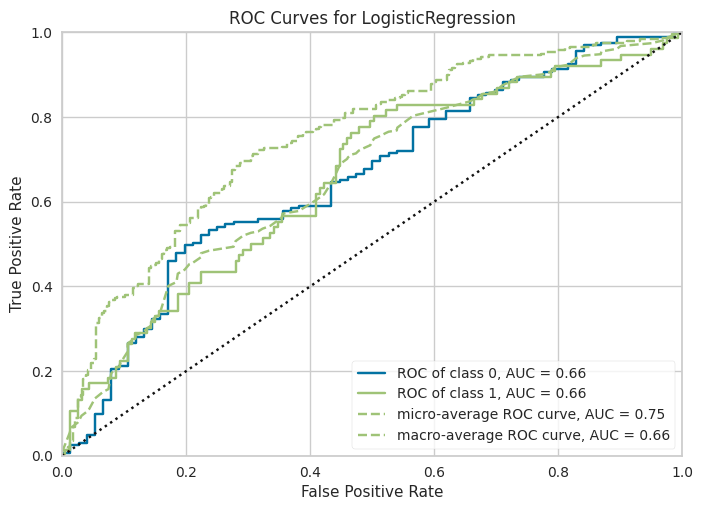

In [30]:
plot_model(granzier_lr, plot='auc')

In [33]:
aim_3_granzier_test = pd.merge(aim_3_test['pCR'], aim_3_test[granzier_features], left_index=True, right_index=True)
predict_model(granzier_lr, data = aim_3_granzier_test)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.6802,0.6859,0.0794,0.5000,0.1370,0.0541,0.0893


,original_shape_Sphericity,wavelet-LLH_glszm_GrayLevelNonUniformity,wavelet-LLH_glszm_ZoneEntropy,wavelet-HHL_glcm_Imc1,wavelet-HHH_glrlm_RunEntropy,wavelet-LLL_glcm_DifferenceVariance,pCR,prediction_label,prediction_score
Patient_ID,,,,,,,,,
695521,0.280307,27.083334,6.046375,-0.053037,2.074927,15.600787,0,0,0.6628
286984,0.178539,577.575928,6.720194,-0.025421,2.478856,23.310661,0,0,0.7751
516834,0.653836,1.750000,2.500000,-0.665229,1.236645,0.474747,0,1,0.5574
941926,0.218088,2045.864990,6.822243,-0.013378,3.329711,51.438736,0,0,0.9016
859699,0.197948,35.440250,5.198004,-0.051489,1.838253,5.459309,1,0,0.6211
...,...,...,...,...,...,...,...,...,...
674897,0.311510,41.337467,5.610764,-0.019521,2.216955,3.039614,0,0,0.6632
221686,0.192803,49.579712,6.191714,-0.089913,2.507791,78.654053,1,0,0.6505
572731,0.396610,10.937500,3.502620,-0.063342,1.496726,0.951236,1,1,0.5017


## Clinical only model

In [40]:
aim_3_clin_train = pd.merge(aim_3_train.loc[:, ['pCR', 'Age_at_Screening', 'cat_menopausal_status']], clinical.loc[:, ['HER2', 'HR']], left_index=True, right_index=True)
aim_3_clin_test = pd.merge(aim_3_test.loc[:, ['pCR', 'Age_at_Screening', 'cat_menopausal_status']], clinical.loc[:, ['HER2', 'HR']], left_index=True, right_index=True)

aim_3_clin_clf = setup(aim_3_clin_train,
                          target='pCR',
                          session_id=42,
                          data_split_stratify=True,
                          fold=5,
                          preprocess=True,
                          categorical_features=['cat_menopausal_status', 'HR', 'HER2'],
                          experiment_name='BRADCURE_aim3_granzier_pcr')


,Description,Value
0,Session id,42
1,Target,pCR
2,Target type,Binary
3,Original data shape,"(788, 5)"
4,Transformed data shape,"(788, 8)"
5,Transformed train set shape,"(551, 8)"
6,Transformed test set shape,"(237, 8)"
7,Numeric features,1
8,Categorical features,3
9,Preprocess,True


In [ ]:
aim_3_clin_clf_best = compare_models(sort= 'AUC', n_select=5)

In [35]:
clin_pcr_lr = create_model('lr')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7297,0.6604,0.1944,0.8750,0.3182,0.2270,0.3278
1,0.6727,0.6469,0.1143,0.4444,0.1818,0.0594,0.0809
2,0.6909,0.6634,0.2286,0.5333,0.3200,0.1596,0.1836
3,0.7000,0.7716,0.1389,0.7143,0.2326,0.1410,0.2150
4,0.6818,0.6443,0.2500,0.5294,0.3396,0.1641,0.1842
Mean,0.6950,0.6773,0.1852,0.6193,0.2784,0.1502,0.1983
Std,0.0196,0.0477,0.0517,0.1552,0.0608,0.0539,0.0791


In [36]:
save_model(clin_pcr_lr, 'data/results/clin_pcr_lr_aim3_pcr')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None, include=['Age_at_Screening'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               missing_values=nan,
                                                               strategy='mean'))),
                 ('categorical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['cat_menopausal_status'...
                                                               handle_missing='return_nan',
                                                               handle_unknown='value',
  

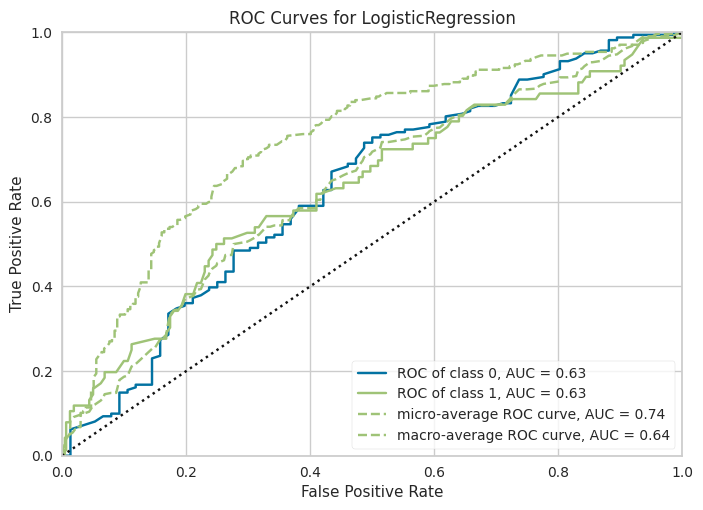

In [37]:
plot_model(clin_pcr_lr, plot='auc')

In [ ]:
predict_model(clin_pcr_lr, data = aim_3_clin_test)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.7056,0.6731,0.2222,0.6087,0.3256,0.1864,0.2252


,Age_at_Screening,cat_menopausal_status,HER2,HR,pCR,prediction_label,prediction_score
Patient_ID,,,,,,,
695521,57.0,NA,0,1,0,0,0.8610
286984,50.0,Premenopausal,0,1,0,0,0.8566
516834,46.0,Premenopausal,0,1,0,0,0.8469
941926,51.0,Postmenopausal,0,1,0,0,0.8051
859699,53.0,Postmenopausal,1,1,1,0,0.6086
...,...,...,...,...,...,...,...
674897,50.0,Premenopausal,0,0,0,0,0.6487
221686,47.0,Postmenopausal,0,0,1,0,0.5419
572731,34.0,Premenopausal,0,1,1,0,0.8146


## Clincial + Volume

In [41]:
aim_3_clinvol_train = pd.merge(aim_3_clin_train, aim_3_train.loc[:, ['original_shape_MeshVolume']], left_index=True, right_index=True)
aim_3_clinvol_test = pd.merge(aim_3_clin_test, aim_3_test.loc[:, ['original_shape_MeshVolume']], left_index=True, right_index=True)

In [42]:
aim_3_clinvol_clf = setup(
    aim_3_clinvol_train,
    target='pCR',
    session_id=42,
    data_split_stratify=True,
    fold=5,
    preprocess=True,
    categorical_features=['cat_menopausal_status', 'HR', 'HER2'],
    experiment_name='BRADCURE_aim3_clinvol_pcr'
)

,Description,Value
0,Session id,42
1,Target,pCR
2,Target type,Binary
3,Original data shape,"(788, 6)"
4,Transformed data shape,"(788, 9)"
5,Transformed train set shape,"(551, 9)"
6,Transformed test set shape,"(237, 9)"
7,Numeric features,2
8,Categorical features,3
9,Preprocess,True


In [44]:
aim_3_clinvol_clf_best = compare_models(sort='auc', n_select=5)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.6951,0.7115,0.1963,0.5926,0.2873,0.1548,0.1948,0.0240
lr,Logistic Regression,0.6770,0.7112,0.2021,0.5016,0.2818,0.1236,0.1457,0.5120
lda,Linear Discriminant Analysis,0.6878,0.7112,0.1963,0.5662,0.2819,0.1412,0.1769,0.0240
gbc,Gradient Boosting Classifier,0.6643,0.6901,0.3659,0.4748,0.4120,0.1835,0.1869,0.0540
ada,Ada Boost Classifier,0.6825,0.6838,0.3654,0.5140,0.4264,0.2155,0.2220,0.0340
lightgbm,Light Gradient Boosting Machine,0.6606,0.6802,0.3876,0.4742,0.4244,0.1879,0.1909,35.8560
rf,Random Forest Classifier,0.6388,0.6464,0.3475,0.4188,0.3775,0.1285,0.1295,0.0660
nb,Naive Bayes,0.5482,0.6423,0.7035,0.3952,0.5009,0.1501,0.1742,0.0240
et,Extra Trees Classifier,0.6153,0.6017,0.3305,0.3819,0.3522,0.0824,0.0829,0.0600
knn,K Neighbors Classifier,0.6099,0.5950,0.2873,0.3623,0.3193,0.0528,0.0531,0.3460


In [47]:
aim_3_clinvol_lr = create_model('lr')

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,20:40:20
Status,. . . . . . . . . . . . . . . . . .,Selecting Estimator
Estimator,. . . . . . . . . . . . . . . . . .,Logistic Regression


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6486,0.6663,0.1667,0.4000,0.2353,0.0550,0.0639
1,0.6818,0.7246,0.1143,0.5000,0.1860,0.0767,0.1093
2,0.7000,0.6884,0.2571,0.5625,0.3529,0.1915,0.2164
3,0.6818,0.7797,0.1667,0.5455,0.2553,0.1206,0.1550
4,0.6727,0.6971,0.3056,0.5000,0.3793,0.1743,0.1841
Mean,0.6770,0.7112,0.2021,0.5016,0.2818,0.1236,0.1457
Std,0.0167,0.0390,0.0692,0.0565,0.0729,0.0531,0.0540


In [48]:
predict_model(aim_3_clinvol_lr, data = aim_3_clinvol_test)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.7411,0.7482,0.2857,0.7500,0.4138,0.2882,0.3436


,Age_at_Screening,cat_menopausal_status,HER2,HR,original_shape_MeshVolume,pCR,prediction_label,prediction_score
Patient_ID,,,,,,,,
695521,57.0,NA,0,1,936.791687,0,0,0.8319
286984,50.0,Premenopausal,0,1,34098.500000,0,0,0.8937
516834,46.0,Premenopausal,0,1,5.916667,0,0,0.8154
941926,51.0,Postmenopausal,0,1,134097.453125,0,0,0.9680
859699,53.0,Postmenopausal,1,1,495.916656,1,0,0.5830
...,...,...,...,...,...,...,...,...
674897,50.0,Premenopausal,0,0,1356.625000,0,0,0.5805
221686,47.0,Postmenopausal,0,0,1701.708374,1,1,0.5245
572731,34.0,Premenopausal,0,1,72.583336,1,0,0.7698


## Clinical + Radiomic model 

In [53]:
aim_3_cr_train = pd.merge(aim_3_clin_train, aim_3_train[granzier_features], left_index=True, right_index=True)
aim_3_cr_test = pd.merge(aim_3_clin_test, aim_3_test[granzier_features], left_index=True, right_index=True)

In [55]:
aim_3_cr_clf = setup(aim_3_cr_train,
                     index=True,
                    target='pCR',
                    session_id=42,
                    data_split_stratify=True,
                    fold=5,
                    preprocess=True,
                    categorical_features=['cat_menopausal_status', 'HR', 'HER2'],
                    experiment_name='BRADCURE_aim3_clinrad_pcr')

,Description,Value
0,Session id,42
1,Target,pCR
2,Target type,Binary
3,Original data shape,"(788, 11)"
4,Transformed data shape,"(788, 14)"
5,Transformed train set shape,"(551, 14)"
6,Transformed test set shape,"(237, 14)"
7,Numeric features,7
8,Categorical features,3
9,Preprocess,True


In [56]:
cr_pcr_lr = create_model('lr')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6036,0.6641,0.1667,0.3000,0.2143,-0.0226,-0.0244
1,0.6455,0.7135,0.1429,0.3571,0.2041,0.0272,0.0319
2,0.7364,0.6941,0.3714,0.6500,0.4727,0.3140,0.3358
3,0.7364,0.7827,0.3056,0.7333,0.4314,0.2958,0.3439
4,0.7273,0.7162,0.4167,0.6250,0.5000,0.3227,0.3352
Mean,0.6898,0.7141,0.2806,0.5331,0.3645,0.1874,0.2045
Std,0.0550,0.0390,0.1089,0.1718,0.1287,0.1522,0.1649


In [47]:
save_model(cr_pcr_lr, 'data/results/cr_pcr_lr_aim3_pcr')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Age_at_Screening',
                                              'original_shape_Sphericity',
                                              'wavelet-LLH_glszm_GrayLevelNonUniformity',
                                              'wavelet-LLH_glszm_ZoneEntropy',
                                              'wavelet-HHL_glcm_Imc1',
                                              'wavelet-HHH_glrlm_RunEntropy',
                                              'wavelet-LLL_glcm_DifferenceVariance'],
                                     transformer=SimpleImputer(a...
                  TransformerWrapper(exclude=None, include=None,
                                     transformer=CleanColumnNames(match='[\\]\\[\\,\\{\\}\\"\\:]+'))),
                 ('trained_model',
                  LogisticRegression(C=1.0, class_weig

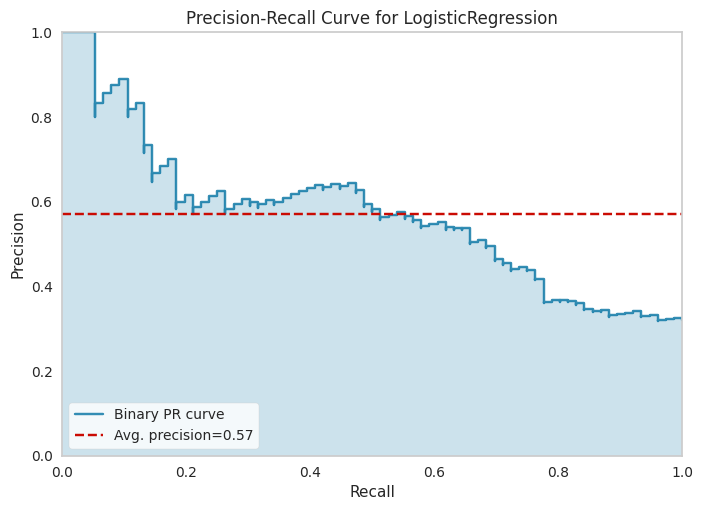

In [51]:
plot_model(cr_pcr_lr, plot='pr')

In [57]:
predict_model(cr_pcr_lr, data=aim_3_cr_test)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.7310,0.7466,0.3651,0.6389,0.4646,0.3024,0.3235


,Age_at_Screening,cat_menopausal_status,HER2,HR,original_shape_Sphericity,wavelet-LLH_glszm_GrayLevelNonUniformity,wavelet-LLH_glszm_ZoneEntropy,wavelet-HHL_glcm_Imc1,wavelet-HHH_glrlm_RunEntropy,wavelet-LLL_glcm_DifferenceVariance,pCR,prediction_label,prediction_score
Patient_ID,,,,,,,,,,,,,
695521,57.0,NA,0,1,0.280307,27.083334,6.046375,-0.053037,2.074927,15.600787,0,0,0.8399
286984,50.0,Premenopausal,0,1,0.178539,577.575928,6.720194,-0.025421,2.478856,23.310661,0,0,0.9106
516834,46.0,Premenopausal,0,1,0.653836,1.750000,2.500000,-0.665229,1.236645,0.474747,0,0,0.6587
941926,51.0,Postmenopausal,0,1,0.218088,2045.864990,6.822243,-0.013378,3.329711,51.438736,0,0,0.9652
859699,53.0,Postmenopausal,1,1,0.197948,35.440250,5.198004,-0.051489,1.838253,5.459309,1,0,0.5720
...,...,...,...,...,...,...,...,...,...,...,...,...,...
674897,50.0,Premenopausal,0,0,0.311510,41.337467,5.610764,-0.019521,2.216955,3.039614,0,0,0.6023
221686,47.0,Postmenopausal,0,0,0.192803,49.579712,6.191714,-0.089913,2.507791,78.654053,1,1,0.5363
572731,34.0,Premenopausal,0,1,0.396610,10.937500,3.502620,-0.063342,1.496726,0.951236,1,0,0.6757
